# Загрузка библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
plt.style.use('ggplot')

# деление на train и test
from sklearn.model_selection import train_test_split

# метрики
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import make_scorer

# проверка гипотез
from scipy.stats import mannwhitneyu

import xgboost as xgb
import optuna
from sklearn.model_selection import StratifiedKFold
from optuna.samplers import TPESampler

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Загрузка и обработка данных

In [2]:
train = pd.read_csv('train.csv', decimal=',', sep=';', low_memory=False)
test = pd.read_csv('test.csv', decimal=',', sep=';', low_memory=False)

# описание переменных
features = pd.read_csv('feature_description.csv', index_col = 0, decimal=',', sep=';', encoding='windows-1251')
features.drop('id', inplace = True)
features['dtypes'] = train.dtypes
train.head()

,id,dt,target,turn_cur_cr_avg_act_v2,salary_6to12m_avg,hdb_bki_total_max_limit,dp_ils_paymentssum_avg_12m,hdb_bki_total_cc_max_limit,incomeValue,gender,...,dp_ils_uniq_companies_1y,avg_6m_travel,avg_6m_government_services,hdb_bki_active_cc_max_overdue,total_rur_amt_cm_avg_period_days_ago_v2,label_Above_1M_share_r1,transaction_category_supermarket_sum_cnt_d15,max_balance_rur_amt_1m_af,w,first_salary_income
0,2,2024-04-30,109324.476325,1465144.960,NaN,52800.0,365346.244634,23213.0,97366.0,Женский,...,1.0,0.0,57.0,0.0,297.0,0.027027,9.0,NaN,0.301217,NaN
1,4,2024-02-29,25558.028662,303593.660,NaN,260200.0,NaN,10000.0,32580.0,Женский,...,NaN,0.0,707.0,67.0,30245.0,NaN,2.0,NaN,0.695800,NaN
2,5,2024-02-29,40666.753098,490754.010,NaN,2000000.0,NaN,90000.0,96866.0,Женский,...,NaN,422.0,0.0,0.0,210322.0,0.000000,20.0,NaN,0.515970,NaN
3,6,2024-04-30,43856.672058,219875.120,NaN,75000.0,NaN,75000.0,43860.0,Мужской,...,NaN,0.0,0.0,0.0,7187.0,0.000000,7.0,NaN,0.478003,NaN
4,7,2024-04-30,130420.851992,1750241.845,NaN,1000000.0,NaN,240000.0,83815.0,Женский,...,NaN,0.0,84.0,0.0,690038.0,0.000000,9.0,NaN,0.552314,NaN


# Категориальные и технические переменные

In [3]:
# категориальные переменные 

CATEGORICAL_FEATURES = [
    'gender', 'adminarea', 'city_smart_name', 'addrref', 
    'dp_ewb_last_employment_position', 'period_last_act_ad',
    'incomeValueCategory'
]

# технические переменные
SYSTEM_COLS = ['id', 'target', 'w', 'dt']

# Числовые переменные

In [4]:
# функция для приведения числовых переменных в правильный формат данных
# и создание флагов наличия данных 

def base_preprocessing(df: pd.DataFrame, dp_col: str = None, bki_col: str = "bki_total_il_max_limit") -> pd.DataFrame:
    res_df = df.copy()
    
    for col in res_df.columns:
        if col in SYSTEM_COLS or col in CATEGORICAL_FEATURES:
            continue
            
        # Если колонка НЕ числовая
        if not pd.api.types.is_numeric_dtype(res_df[col]):
            cleaned_series = res_df[col].astype(str).str.replace(r'[\s\xa0]', '', regex=True).str.replace(',', '.', regex=False)
            res_df[col] = pd.to_numeric(cleaned_series, errors="coerce")
        else:
            res_df[col] = pd.to_numeric(res_df[col], errors="coerce")
            

    new_flags = {}

    # Флаг наличия данных о средней зарплате
    if "salary_6to12m_avg" in res_df.columns:
        new_flags["has_salary_6to12m_data"] = res_df["salary_6to12m_avg"].notna().astype(int)
    else:
        new_flags["has_salary_6to12m_data"] = 0
        
    # Флаг наличия Цифрового Профиля
    if dp_col and dp_col in res_df.columns:
        new_flags["has_dp"] = res_df[dp_col].notna().astype(int)
    else:
        new_flags["has_dp"] = 0

    # Флаг наличия БКИ по ключевому признаку
    if bki_col and bki_col in res_df.columns:
        new_flags["has_bki"] = res_df[bki_col].notna().astype(int)
    else:
        new_flags["has_bki"] = 0

    return pd.concat([res_df, pd.DataFrame(new_flags, index=res_df.index)], axis=1)

dp_cols_train = [i for i in train.columns if i.startswith('dp_')]
not_Nan_train = train[dp_cols_train].notna().sum()
dp_col_name = not_Nan_train[not_Nan_train == not_Nan_train.max()].index[0]

train_clean = base_preprocessing(train, dp_col_name)
test_clean = base_preprocessing(test, dp_col_name)

train_clean

,id,dt,target,turn_cur_cr_avg_act_v2,salary_6to12m_avg,hdb_bki_total_max_limit,dp_ils_paymentssum_avg_12m,hdb_bki_total_cc_max_limit,incomeValue,gender,...,hdb_bki_active_cc_max_overdue,total_rur_amt_cm_avg_period_days_ago_v2,label_Above_1M_share_r1,transaction_category_supermarket_sum_cnt_d15,max_balance_rur_amt_1m_af,w,first_salary_income,has_salary_6to12m_data,has_dp,has_bki
0,2,2024-04-30,109324.476325,1465144.960,NaN,52800.0,365346.244634,23213.0,97366.0,Женский,...,0.00,297.0,0.027027,9.0,NaN,0.301217,NaN,0,1,1
1,4,2024-02-29,25558.028662,303593.660,NaN,260200.0,NaN,10000.0,32580.0,Женский,...,67.00,30245.0,NaN,2.0,NaN,0.695800,NaN,0,0,1
2,5,2024-02-29,40666.753098,490754.010,NaN,2000000.0,NaN,90000.0,96866.0,Женский,...,0.00,210322.0,0.000000,20.0,NaN,0.515970,NaN,0,0,0
3,6,2024-04-30,43856.672058,219875.120,NaN,75000.0,NaN,75000.0,43860.0,Мужской,...,0.00,7187.0,0.000000,7.0,NaN,0.478003,NaN,0,0,1
4,7,2024-04-30,130420.851992,1750241.845,NaN,1000000.0,NaN,240000.0,83815.0,Женский,...,0.00,690038.0,0.000000,9.0,NaN,0.552314,NaN,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76781,149993,2024-06-30,68976.691400,NaN,NaN,NaN,NaN,NaN,NaN,Мужской,...,NaN,0.0,NaN,NaN,NaN,0.179016,NaN,0,0,0
76782,149994,2024-01-31,50768.829700,NaN,NaN,NaN,NaN,NaN,NaN,Женский,...,NaN,0.0,NaN,NaN,NaN,0.395732,NaN,0,0,0
76783,149996,2024-06-30,30613.920000,432098.090,32967.213362,140000.0,NaN,140000.0,153541.0,Мужской,...,4798.00,20802.0,NaN,2.0,NaN,0.635623,NaN,1,0,1
76784,149998,2024-05-31,81547.761138,3485.000,NaN,19500.0,NaN,0.0,118742.0,Мужской,...,NaN,0.0,0.000000,NaN,NaN,0.029391,NaN,0,0,1


In [5]:
# список числовых переменных
base_features_list = [
    col for col in train.columns 
    if col not in SYSTEM_COLS and col not in ["has_salary_6to12m_data", "has_dp", "has_bki", "target", "w", "dt"]
]

# заполняем пропуски в категориальных фичах
for df_clean in [train_clean, test_clean]:
    for col in CATEGORICAL_FEATURES:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].fillna('missing').astype(str)

train_clean

,id,dt,target,turn_cur_cr_avg_act_v2,salary_6to12m_avg,hdb_bki_total_max_limit,dp_ils_paymentssum_avg_12m,hdb_bki_total_cc_max_limit,incomeValue,gender,...,hdb_bki_active_cc_max_overdue,total_rur_amt_cm_avg_period_days_ago_v2,label_Above_1M_share_r1,transaction_category_supermarket_sum_cnt_d15,max_balance_rur_amt_1m_af,w,first_salary_income,has_salary_6to12m_data,has_dp,has_bki
0,2,2024-04-30,109324.476325,1465144.960,NaN,52800.0,365346.244634,23213.0,97366.0,Женский,...,0.00,297.0,0.027027,9.0,NaN,0.301217,NaN,0,1,1
1,4,2024-02-29,25558.028662,303593.660,NaN,260200.0,NaN,10000.0,32580.0,Женский,...,67.00,30245.0,NaN,2.0,NaN,0.695800,NaN,0,0,1
2,5,2024-02-29,40666.753098,490754.010,NaN,2000000.0,NaN,90000.0,96866.0,Женский,...,0.00,210322.0,0.000000,20.0,NaN,0.515970,NaN,0,0,0
3,6,2024-04-30,43856.672058,219875.120,NaN,75000.0,NaN,75000.0,43860.0,Мужской,...,0.00,7187.0,0.000000,7.0,NaN,0.478003,NaN,0,0,1
4,7,2024-04-30,130420.851992,1750241.845,NaN,1000000.0,NaN,240000.0,83815.0,Женский,...,0.00,690038.0,0.000000,9.0,NaN,0.552314,NaN,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76781,149993,2024-06-30,68976.691400,NaN,NaN,NaN,NaN,NaN,NaN,Мужской,...,NaN,0.0,NaN,NaN,NaN,0.179016,NaN,0,0,0
76782,149994,2024-01-31,50768.829700,NaN,NaN,NaN,NaN,NaN,NaN,Женский,...,NaN,0.0,NaN,NaN,NaN,0.395732,NaN,0,0,0
76783,149996,2024-06-30,30613.920000,432098.090,32967.213362,140000.0,NaN,140000.0,153541.0,Мужской,...,4798.00,20802.0,NaN,2.0,NaN,0.635623,NaN,1,0,1
76784,149998,2024-05-31,81547.761138,3485.000,NaN,19500.0,NaN,0.0,118742.0,Мужской,...,NaN,0.0,0.000000,NaN,NaN,0.029391,NaN,0,0,1


In [6]:
train_clean.dtypes.value_counts()

float64    215
str          8
int64        4
Name: count, dtype: int64

In [7]:
test_clean.dtypes.value_counts()

float64    213
str          8
int64        4
Name: count, dtype: int64

# Пропуски

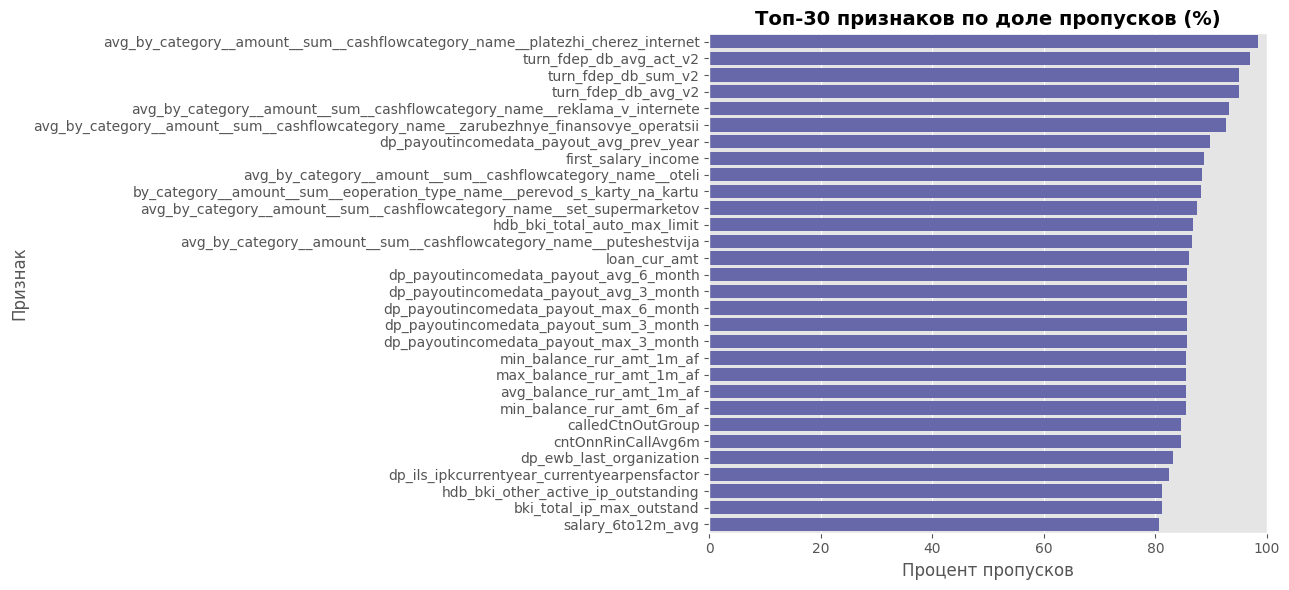

,count,mean,std,min,25%,50%,75%,max
miss%,211.0,43.127191,29.445421,0.794416,21.582059,28.777381,78.452452,98.441122


In [8]:
features['miss%'] = train_clean.isnull().sum() / train_clean.shape[0] * 100
miss = features[features['miss%'] > 0].sort_values(by = 'miss%', ascending = False)

plt.figure(figsize=(13, 6))
sns.barplot(data= miss.head(30), x='miss%', y = miss.head(30).index, color = "#5B5EB481")
plt.title('Топ-30 признаков по доле пропусков (%)', fontsize = 14, fontweight = 'bold')
plt.xlabel('Процент пропусков')
plt.ylabel('Признак')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

miss.describe().T

__Вывод__

***************
Больше всего пропусков в данных, связанных с цифровым профилем, а также с БКИ
***************

# Анализ таргета

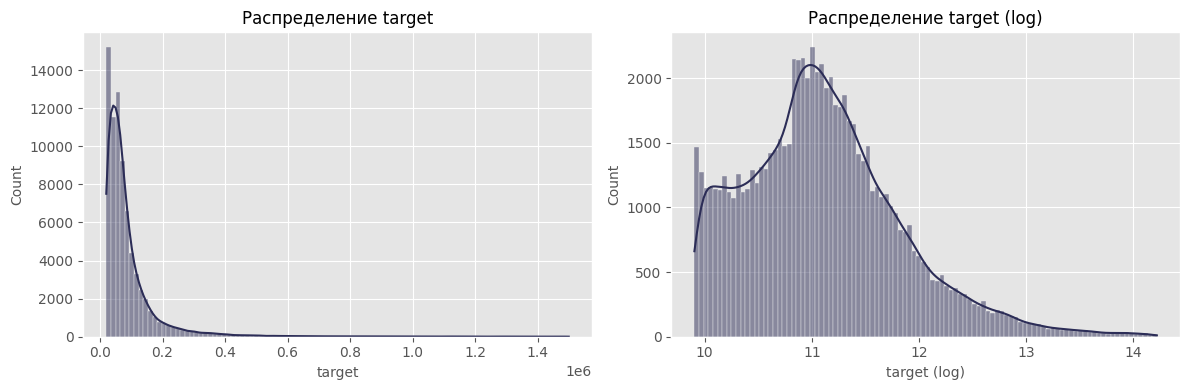

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data = train_clean, 
    x = train_clean['target'], 
    bins=100, 
    kde=True,
    ax=ax1, 
    color="#2c2d57"
)
ax1.set_title('Распределение target', fontsize=12, )
ax1.set_xlabel('target', fontsize=10)
ax1.set_ylabel('Count', fontsize=10)

sns.histplot(
    data = train_clean, 
    x = np.log1p(train_clean['target']), 
    bins=100, 
    kde=True,
    ax=ax2, 
    color="#2c2d57"
)
ax2.set_title('Распределение target (log)', fontsize=12)
ax2.set_xlabel('target (log)', fontsize=10)
ax2.set_ylabel('Count', fontsize=10)

plt.tight_layout()
plt.show()

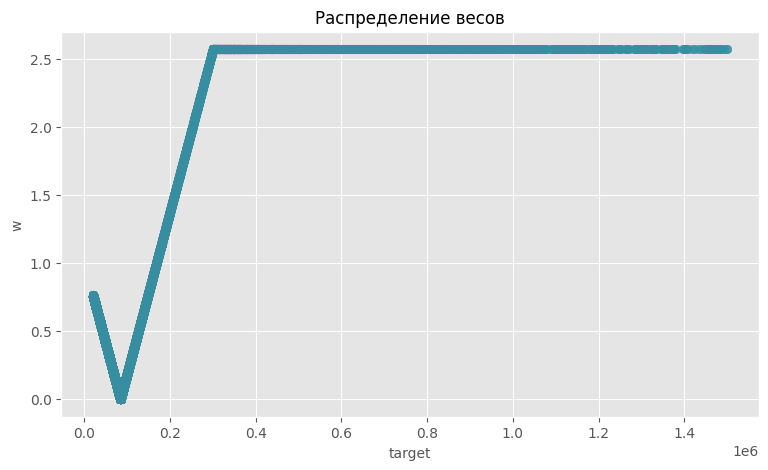

In [10]:
# Распредление весов
plt.figure(figsize = (9, 5))
plt.scatter(train['target'], train['w'], color = "#378EA196")
plt.title('Распределение весов', fontsize = 12)
plt.xlabel('target', fontsize = 10)
plt.ylabel('w', fontsize = 10)
plt.show()

__Вывод__

***************
Распределение целевой переменной сильно скошено. Есть клиенты с экстремальными доходами
***************

#  Обработка категориальных переменных

### Генедер

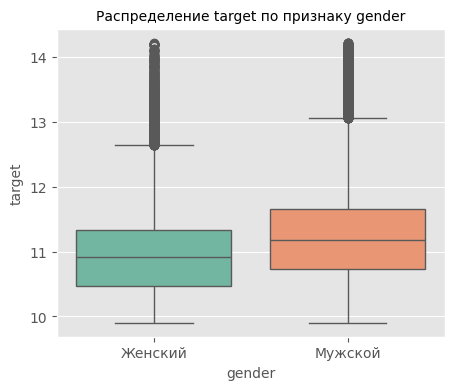

Статистика: 577705502.0000
P-value: 0.0000e+00
------------------------------------
Различия статистически значимы


In [11]:
plt.figure(figsize = (5, 4))
sns.boxplot(data = train_clean, 
            x = train_clean['gender'] , 
            y = np.log1p(train_clean['target']),  
            hue = train['gender'], 
            palette = 'Set2')

plt.ylabel('target', fontsize=10)
plt.xlabel('gender', fontsize=10)
plt.title('Распределение target по признаку gender', fontsize = 10)
plt.show()

# статистическая проверка 
group_0 = train_clean[train_clean['gender'] == 'Женский']['target']
group_1 = train_clean[train_clean['gender'] == 'Мужской']['target']
stat, p_value = mannwhitneyu(group_0, group_1, alternative = 'two-sided')

print(f'Статистика: {stat:.4f}')
print(f'P-value: {p_value:.4e}')

if p_value < 0.05:
    print("------------------------------------\nРазличия статистически значимы")
else:
    print("------------------------------------\nСтатистически значимых различий нет")

### Профессии

In [12]:
train_clean['dp_ewb_last_employment_position'] = train_clean['dp_ewb_last_employment_position'].str.lower().str.replace(r'\s*-\s*', '-', regex=True).str.replace('ё', 'е').str.strip()
test_clean['dp_ewb_last_employment_position']  = test_clean['dp_ewb_last_employment_position'].str.lower().str.replace(r'\s*-\s*', '-', regex=True).str.replace('ё', 'е').str.strip()

# замена ошибок
typo_dict = {
    'генральный директор': 'генеральный директор',
    'директоор': 'директор',
    'бухталтер тмц': 'бухгалтер',
    'овар': 'повар',
    'фельдшнр-лаборант': 'фельдшер-лаборант',
    'мерчандайзер': 'мерчендайзер',
    'сброщик': 'сборщик',
    'официанть': 'официант',
    'слесать-механик': 'слесарь-механик',
    'ветеринарнай врач': 'ветеринарный врач',
    'чистильщк': 'чистильщик',
    'помошник': 'помощник',
    'менеджера': 'менеджер',
    'ген.директор': 'генеральный директор',
    'директор филиала .': 'директор филиала',
    'директор склада.': 'директор склада',
    'операционный менеджер.': 'операционный менеджер',
    'инженер.': 'инженер',
    'специалист.': 'специалист',
    'уборщ. служ. пом': 'уборщик служебных помещений',
    'сборщих свинцовых акб': 'сборщик свинцовых акб'
}
train_clean['dp_ewb_last_employment_position'] = train_clean['dp_ewb_last_employment_position'].replace(typo_dict)
test_clean['dp_ewb_last_employment_position']  = test_clean['dp_ewb_last_employment_position'].replace(typo_dict)

# Словарь смыслового объединения (Синонимы)

merge_dict = {
    # Розница и продажи
    'продавец - кассир': 'продавец-кассир',
    'продавец-консультант (кассир)' : 'продавец-кассир',
    'продавец-кассир сменный': 'продавец-кассир',
    'продавец-кассир, 3 категория' : 'продавец-кассир',
    'кассир-продавец': 'продавец-кассир',
    'продавец консультант': 'продавец-консультант',
    'продавец-консультант первого грейда': 'продавец-консультант',
    'дизайнер-продавец': 'продавец-консультант',
    'администратор-кассир': 'продавец-кассир',
    'менеджер отдела продаж': 'менеджер по продажам',
    'менеджер прямых продаж': 'менеджер по продажам',
    'менеджер по прямым продажам': 'менеджер по продажам',
    'менеджер по продажам дст':'менеджер по продажам',
    'менеджер активных продаж': 'менеджер по продажам',
    'менеджер по продажам ': 'менеджер по продажам',
    'продавец-кассир (19.1у группа)': 'продавец-кассир', #[cite: 2]
    'продавец-кассир (18.1у группа)': 'продавец-кассир', #[cite: 2]
    'продавец-кассир (2.4у группа)': 'продавец-кассир', #[cite: 2]
    'продавец-кассир (17.5у группа)': 'продавец-кассир', #[cite: 2]
    'продавец-кассир (9.1у е группа)': 'продавец-кассир', #[cite: 2]
    'продавец-кассир магазина рестор категории а': 'продавец-кассир', #[cite: 2]
    '_старший продавец-кассир': 'продавец-кассир', #[cite: 2]
    'кассир-консультант': 'продавец-кассир', #[cite: 2]
    'продавец-консультант-кассир': 'продавец-кассир', #[cite: 2]
    'младший продавец': 'продавец-консультант', #[cite: 2]
    'старший продавец-стажер': 'продавец-консультант', #[cite: 2]
    'продавец универсал': 'продавец-универсал', #[cite: 2]
    'продавец-универсал магазина': 'продавец-универсал', #[cite: 2]
    'менеджер продаж': 'менеджер по продажам', #[cite: 2]
    'менеджер по продажам 2 категории': 'менеджер по продажам', #[cite: 2]
    'менеджер по продажам 3 категории': 'менеджер по продажам', #[cite: 2]
    'менеджер по продажам автомобилей': 'менеджер по продажам', #[cite: 2]
    'менеджер по продаже автомобилей': 'менеджер по продажам', #[cite: 2]
    'менеджер по продаже автомобилей обособленного подразделения в г.екатеринбург': 'менеджер по продажам', #[cite: 2]
    'менеджер по продажам транспортных средств': 'менеджер по продажам', #[cite: 2]
    'менеджер по продажам консультантплюс': 'менеджер по продажам', #[cite: 2]
    'менеджер по продажам кредитных продуктов': 'менеджер по продажам', #[cite: 2]
    'старший менеджер по продажам': 'менеджер по продажам', #[cite: 2]
    'менеджер по продажам-специалист по тендерам': 'менеджер по продажам', #[cite: 2]
    
    # Руководство магазинами
    'управляющий магазином': 'директор магазина',
    'заведующий магазином': 'директор магазина',
    'директор универсама': 'директор магазина',
    'директор супермаркета': 'директор магазина',
    'заместитель директора магазина': 'заместитель директора магазина',
    # Руководство магазинами
    'управляющий магазина': 'директор магазина', #[cite: 2]
    'управляющий (ая)': 'директор магазина', #[cite: 2]
    'заместитель директора магазина-стажер': 'заместитель директора магазина', #[cite: 2]
    'заместитель директора супермаркета': 'заместитель директора магазина', #[cite: 2]    

    # Склад и Логистика
    'кладовщик-комплектовщик': 'кладовщик',
    'кладовщик;служащие, занятые учетом, приемом и выдачей товаров на складе': 'кладовщик',
    'кладовщик-отборщик': 'кладовщик',
    'кладовщик склада': 'кладовщик',
    'кладовщик магазина': 'кладовщик',
    'водитель автомобиля': 'водитель',
    'водитель грузового автомобиля': 'водитель',
    'водитель легкового автомобиля': 'водитель',
    'водитель трамвая на регулярных городских пассажирских маршрутах, трамвай': 'водитель',
    'водитель автопогрузчика': 'водитель погрузчика',
    'водитель электропогрузчика': 'водитель погрузчика',
    'машинист погрузчика': 'водитель погрузчика',
    # Склад и Логистика
    'кладовщик 12759': 'кладовщик', #[cite: 2]
    'кладовщик 2 категории': 'кладовщик', #[cite: 2]
    'кладовщик 1 категории': 'кладовщик', #[cite: 2]
    'кладовщик, 3 разряд': 'кладовщик', #[cite: 2]
    'кладовщик 2 разряда': 'кладовщик', #[cite: 2]
    'кладовщик ррц': 'кладовщик', #[cite: 2]
    'кладовщик холодильной камеры': 'кладовщик', #[cite: 2]
    'кладовщик склада готовой продукции': 'кладовщик', #[cite: 2]
    'служащие, занятые учетом, приемом и выдачей товаров на складе': 'кладовщик', #[cite: 2]
    'кладовщик-комплектовщик (стажер)': 'кладовщик', #[cite: 2]
    'кладовщик-наборщик': 'кладовщик', #[cite: 2]
    'заместитель начальника склада': 'заместитель начальника склада', #[cite: 2]
    'заместитель заведующего складом': 'заместитель начальника склада', #[cite: 2]
    'заместитель управляющего складом': 'заместитель начальника склада', #[cite: 2]
    'заведующим склада': 'заведующий складом', #[cite: 2]
    'заведующая(ий)  складом': 'заведующий складом', #[cite: 2]
    'заведующий  складом': 'заведующий складом', #[cite: 2]
    'водитель  автомобиля': 'водитель', #[cite: 2]
    'водитель автомобиля 7 разряда': 'водитель', #[cite: 2]
    'водитель автомобиля 6 разряда': 'водитель', #[cite: 2]
    'водитель автомобиля 5 разряд (5 категория)': 'водитель', #[cite: 2]
    'водитель автомобиля (вахта)': 'водитель', #[cite: 2]
    'водитель автомобиля 2 класса': 'водитель', #[cite: 2]
    'водитель автомобиля, 7 разряд': 'водитель', #[cite: 2]
    'водитель автомобиля (уаз 19726, uaz 29893) 5 разряда': 'водитель', #[cite: 2]
    'водитель автомобиля, 5 разряд': 'водитель', #[cite: 2]
    'водитель автомобиля (4 разряд)': 'водитель', #[cite: 2]
    'водитель автомобиля, вторая группа, грузоподъемность до 10 тн': 'водитель', #[cite: 2]
    'водитель автомобиля (легкового)': 'водитель', #[cite: 2]
    'водитель категории с': 'водитель', #[cite: 2]
    'водитель категории д': 'водитель', #[cite: 2]
    'водитель (автосамосвала)': 'водитель', #[cite: 2]
    'водитель уаз': 'водитель', #[cite: 2]
    'водитель грузового автомобиля (с допог)': 'водитель', #[cite: 2]
    'водитель грузовых автомобилей': 'водитель', #[cite: 2]
    'водитель грузового автотраспорта': 'водитель', #[cite: 2]
    'водитель погрузо-разгрузочной техники': 'водитель погрузчика', #[cite: 2]
    'водитель электроштабелера': 'водитель погрузчика', #[cite: 2]
    'водитель мини погрузчика': 'водитель погрузчика', #[cite: 2]
    'водитель погрузчика 6 разряда': 'водитель погрузчика', #[cite: 2]
    'водитель погрузчика 4 разряда': 'водитель погрузчика', #[cite: 2]
    'водитель погрузчика, 3 разряд': 'водитель погрузчика', #[cite: 2]
    'грузчик, 2 разряд': 'грузчик', #[cite: 2]
    'грузчик  2 разряда': 'грузчик', #[cite: 2]
    'грузчик 2 разр.': 'грузчик', #[cite: 2]    
    # Уборка
    'уборщик служебных и производственных помещений': 'уборщик производственных и служебных помещений',
    'уборщица': 'уборщик служебных помещений',
    'уборщик помещений': 'уборщик служебных помещений',
    'уборщик производственных помещений': 'уборщик производственных и служебных помещений',
    'уборщик торгового помещения': 'уборщик служебных помещений',
    'уборщик моп': 'уборщик служебных помещений',
# Уборка
    'уборщик  служебных помещений': 'уборщик служебных помещений', #[cite: 2]
    'уборщица служебных помещений': 'уборщик служебных помещений', #[cite: 2]
    'уборщик служебных помещений 1 разряд': 'уборщик служебных помещений', #[cite: 2]
    'уборщик служебных помещений 0,5 ст.': 'уборщик служебных помещений', #[cite: 2]
    'уборщик служебных помещений 1 разрял ектс': 'уборщик служебных помещений', #[cite: 2]
    'уборщик служебных помещений (1разряд)': 'уборщик служебных помещений', #[cite: 2]
    'уборщик служебных помещений 1 разряда': 'уборщик служебных помещений', #[cite: 2]
    'уборщик служебных помещений, 5 разряд (категория)': 'уборщик служебных помещений', #[cite: 2]
    'уборщица служебных помещений и прилегающей территории': 'уборщик служебных помещений', #[cite: 2]
    'уборщик производственных и служебных помещений 2 разряда': 'уборщик производственных и служебных помещений', #[cite: 2]
    'уборщик производственных и служебных помещений категория 283': 'уборщик производственных и служебных помещений', #[cite: 2]
    'уборщик производственных и служебных помещений категория 342': 'уборщик производственных и служебных помещений', #[cite: 2]
    'уборщица мкд': 'уборщик служебных помещений', #[cite: 2]
    'уборщица рожественского д.1': 'уборщик служебных помещений', #[cite: 2]

    # Медицина
    'мед. сестра': 'медицинская сестра',
    'медсестра': 'медицинская сестра',
    'медицинский брат': 'медицинская сестра',
    'медицинская сестра палатная (постовая)': 'медицинская сестра',
    'медицинская сестра приемное отделение' : 'медицинская сестра',
    'медицинская сестра процедурной': 'медицинская сестра',
    'медицинская сестра-анестезист': 'медицинская сестра',
    'младшая медицинская сестра по уходу за больными': 'медицинская сестра',
    'санитарка': 'санитар',
    'санитар(ка)': 'санитар',
# Медицина
    'медсестра (медицинский брат)': 'медицинская сестра', #[cite: 2]
    'медицинская сестра (медбрат) палатная (постовая)': 'медицинская сестра', #[cite: 2]
    'медицинская сестра (медицинский брат)-анестезист': 'медицинская сестра', #[cite: 2]
    'медицинская сестра(брат) по массажу': 'медицинская сестра', #[cite: 2]
    'медицинская сестра приемного отделения': 'медицинская сестра', #[cite: 2]
    'медицинская сестра процедурная': 'медицинская сестра', #[cite: 2]
    'медицинская сестра скорой мед. помощи': 'медицинская сестра', #[cite: 2]
    'медицинская сестра для амбулаторного приема (взрослого населения)': 'медицинская сестра', #[cite: 2]
    'медицинская сестра стоматологического кабинета': 'медицинская сестра', #[cite: 2]
    'медсестра процедурного кабинета': 'медицинская сестра', #[cite: 2]
    'медицинская сестра палатная (27-гд)': 'медицинская сестра', #[cite: 2]
    'медицинская сестра участковая, вторая категория': 'медицинская сестра', #[cite: 2]
    'санитарка (мойщица)': 'санитар', #[cite: 2]

    # Рабочие специальности
    'слесарь мср': 'слесарь механосборочных работ',
    'слесарь механо-сборочных работ': 'слесарь механосборочных работ',
    'оператор станков с чпу': 'оператор станков с программным управлением',
    'оператор чпу': 'оператор станков с программным управлением',
    'подсобный рабочий': 'подсобный рабочий',
    'разнорабочий': 'подсобный рабочий',
# Рабочие специальности
    'слесарь механосборочных работ 4 разряда': 'слесарь механосборочных работ', #[cite: 2]
    'слесарь механосборочных работ 2 разряда': 'слесарь механосборочных работ', #[cite: 2]
    'слесарь механосборочных работ, 4 разряд (категория)': 'слесарь механосборочных работ', #[cite: 2]
    'слесарь механосборочных работ, 3 разряд (категория)': 'слесарь механосборочных работ', #[cite: 2]
    'слесарь механосборочных работ третьего разряда': 'слесарь механосборочных работ', #[cite: 2]
    'слесарь механосборочных работ, 4 разряд': 'слесарь механосборочных работ', #[cite: 2]
    'слесарь механосборочных работ 4 разряда.': 'слесарь механосборочных работ', #[cite: 2]
    'слесарь механосборочных работ 3 разряд': 'слесарь механосборочных работ', #[cite: 2]
    'слесарь механосборочных работ 4-го разряда': 'слесарь механосборочных работ', #[cite: 2]
    'слесарь механосборочных работ, 3 разряд': 'слесарь механосборочных работ', #[cite: 2]
    'слесарь механосборочных работ 3-го разряда': 'слесарь механосборочных работ', #[cite: 2]
    'слесарь механо-сборочных работ 4 разряда': 'слесарь механосборочных работ', #[cite: 2]
    'слесарь мср 3 разряда': 'слесарь механосборочных работ', #[cite: 2]
    'слесарь мех.сбор.работ,2 разряда': 'слесарь механосборочных работ', #[cite: 2]
    'слесарь мср (7222.3)': 'слесарь механосборочных работ', #[cite: 2]
    'оператор станков с программным управлением, 4 разряд': 'оператор станков с программным управлением', #[cite: 2]
    'оператор станков с программным управлением, 3 рязряд': 'оператор станков с программным управлением', #[cite: 2]
    'оператор станков с программным управлением 3 разряд / код тарифной сетки 0212': 'оператор станков с программным управлением', #[cite: 2]
    'оператор станков с программным управлением (ученик)': 'оператор станков с программным управлением', #[cite: 2]
    'оператор станков с программным управлением (чпу)': 'оператор станков с программным управлением', #[cite: 2]
    'оператор станка с программным управлением': 'оператор станков с программным управлением', #[cite: 2]
    'оператор станка с чпу': 'оператор станков с программным управлением', #[cite: 2]
    'оператор станков чпу': 'оператор станков с программным управлением', #[cite: 2]
    'оператор станков с чпу 4 разряда': 'оператор станков с программным управлением', #[cite: 2]
    'подсобный рабочий 2 разряда': 'подсобный рабочий', #[cite: 2]
    'подсобный рабочий 3 разряда': 'подсобный рабочий', #[cite: 2]
    'подсобный рабочий, 2 разряд (категория)': 'подсобный рабочий', #[cite: 2]
    'подсобный рабочий, 2 разряд': 'подсобный рабочий', #[cite: 2]
    'подсобный рабочий (2-й разряд)': 'подсобный рабочий', #[cite: 2]
    'подсобный рабочий 2 раз.': 'подсобный рабочий', #[cite: 2]
    'подсобный   рабочий': 'подсобный рабочий', #[cite: 2]
    'рабочий подсобный': 'подсобный рабочий', #[cite: 2]
    'подсобный рабочий первого разряда': 'подсобный рабочий', #[cite: 2]
    'подсобный рабочий ( энергослужба)': 'подсобный рабочий', #[cite: 2]

    # Топ-менеджмент
    'генеральный директор.ауп.': 'генеральный директор',
    'исполнительный директор': 'генеральный директор',
    # Топ-менеджмент
    'ген. директор': 'генеральный директор', #[cite: 2]
    'генеральный  директор': 'генеральный директор', #[cite: 2]
    'генер.директор': 'генеральный директор', #[cite: 2]
    'генеральный дирекор': 'генеральный директор', #[cite: 2]
    'зам. ген. директора': 'заместитель генерального директора', #[cite: 2]
    'генеральный директор.': 'генеральный директор', #[cite: 2]
    'генеральный директор. администрация': 'генеральный директор', #[cite: 2]
    'генеральный директор предприятия': 'генеральный директор', #[cite: 2]
    'генеральный директор.руководитель учреждения, огранизаций и предприятий.основное подразделение': 'генеральный директор', #[cite: 2]    
}
train_clean['dp_ewb_last_employment_position'] = train_clean['dp_ewb_last_employment_position'].replace(merge_dict)
test_clean['dp_ewb_last_employment_position'] = test_clean['dp_ewb_last_employment_position'].replace(merge_dict)

# обработка юрист
mask = train_clean['dp_ewb_last_employment_position'].str.contains('юрист', case=False, na=False)
mask_test = test_clean['dp_ewb_last_employment_position'].str.contains('юрист', case=False, na=False)
train_clean.loc[mask, 'dp_ewb_last_employment_position'] = 'юрист'
test_clean.loc[mask_test, 'dp_ewb_last_employment_position'] = 'юрист'

In [13]:
job = train_clean.groupby('dp_ewb_last_employment_position')['target'].agg(['count', 'mean']).sort_values(by = 'count', ascending = False).head(15).reset_index()

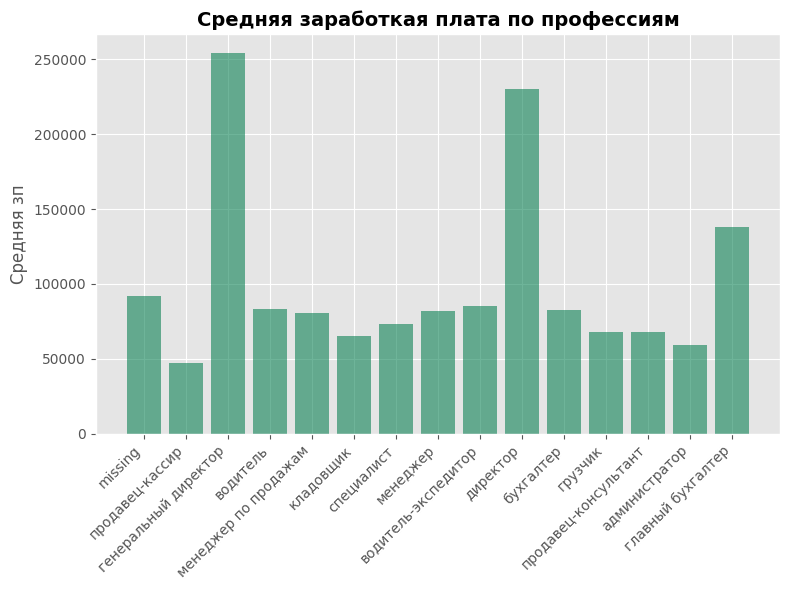

In [14]:
plt.figure(figsize=(8, 6))

plt.bar(range(len(job)),job['mean'], color = "#007c4c91")
plt.xticks(range(len(job)), job['dp_ewb_last_employment_position'], rotation=45, ha='right')
plt.title('Средняя заработкая плата по профессиям', fontsize=14, fontweight='bold')
plt.ylabel('Средняя зп')
plt.tight_layout()
plt.show()

# Признаки заработной платы

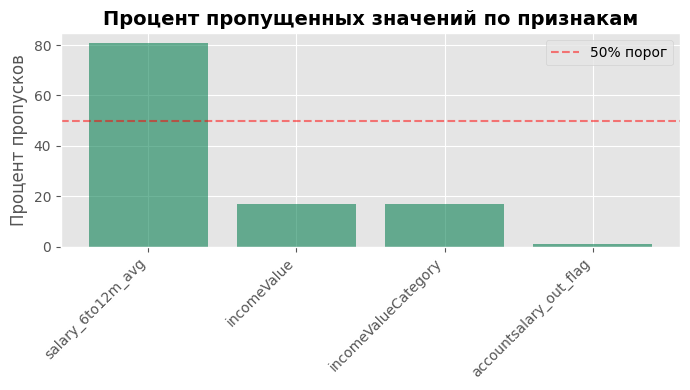

In [15]:
wage = [
    'salary_6to12m_avg',
    'incomeValue',
    'incomeValueCategory',
    'accountsalary_out_flag'
]

plt.figure(figsize=(7, 4))
missing = train[wage].isnull().sum()
missing_pct = (missing / len(train[wage])) * 100

plt.bar(range(len(missing)), missing_pct, color = "#007c4c91")
plt.xticks(range(len(missing)), missing.index, rotation=45, ha='right')
plt.title('Процент пропущенных значений по признакам', fontsize=14, fontweight='bold')
plt.ylabel('Процент пропусков')
plt.axhline(y=50, color='r', linestyle='--', alpha=0.5, label='50% порог')
plt.legend()
plt.tight_layout()
plt.show()

Проанализируем корреляцию

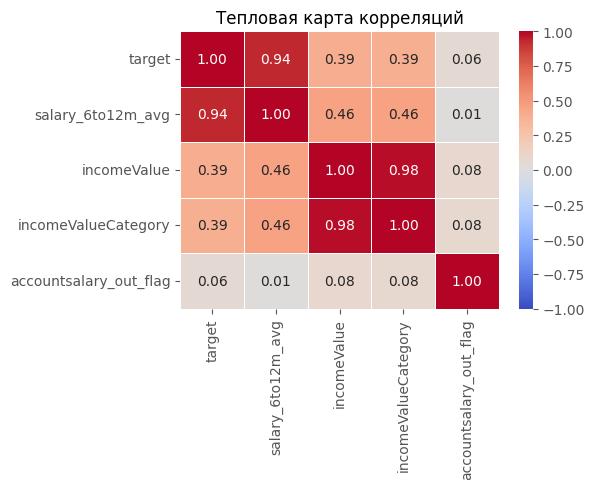

In [16]:
def plot_feature_correlation_heatmap(df):
    num_cols = df.select_dtypes(include=[np.number]).columns
    corr_matrix = df[num_cols].corr(method='spearman')
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5,vmin=-1, vmax = 1)
    plt.title('Тепловая карта корреляций', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_feature_correlation_heatmap(train[['target'] + wage])

* salary_6to12m_avg очень информативный признак (94 % корреляция), но в данной переменной 80% пропусков. 
* incomeVAlue и incomeValueCategory скорее всего дублируют друг друга, а также имеют одинаковую зависимость с таргетом. Скорее всего одна переменная получена из другой. Оставим только одну из них - incomeVAlue
* флаг зарплатного аккаунта слабо коррелирует с таргетом

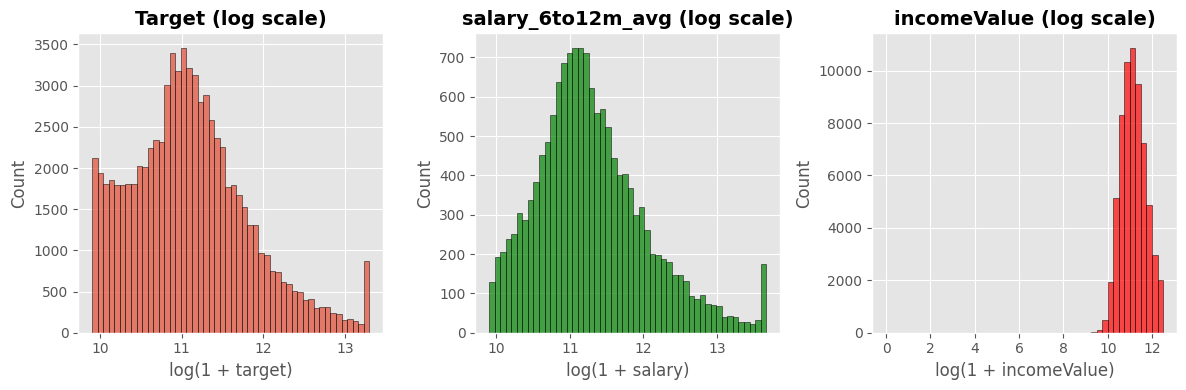

In [17]:
# РАСПРЕДЕЛЕНИЯ
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].hist(np.log1p(train['target'].clip(upper=train['target'].quantile(0.99))), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Target (log scale)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('log(1 + target)')
axes[0].set_ylabel('Count')

salary_data = train['salary_6to12m_avg'].dropna()
axes[1].hist(np.log1p(salary_data.clip(upper=salary_data.quantile(0.99))), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('salary_6to12m_avg (log scale)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log(1 + salary)')
axes[1].set_ylabel('Count')

income_data = train['incomeValue'].dropna()
axes[2].hist(np.log1p(income_data.clip(upper=income_data.quantile(0.99))), bins=50, edgecolor='black', alpha=0.7, color='red')
axes[2].set_title('incomeValue (log scale)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('log(1 + incomeValue)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

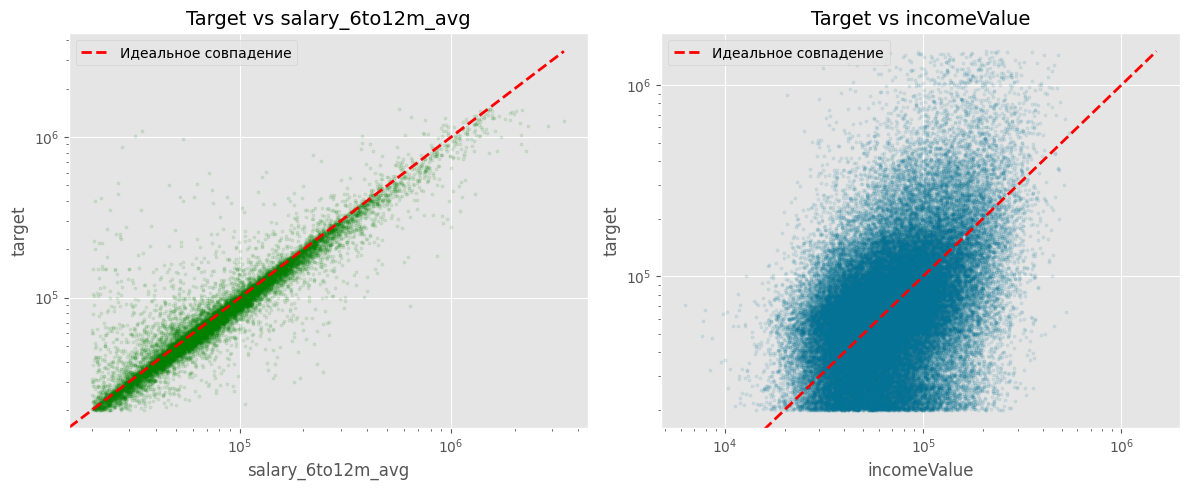

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# График 1: salary_6to12m_avg 
mask_salary = ~train['salary_6to12m_avg'].isna()
data_s = train.loc[mask_salary]

axes[0].scatter(data_s['salary_6to12m_avg'], data_s['target'], 
                alpha=0.1, s=5, color='green')

max_val = max(data_s['salary_6to12m_avg'].max(), data_s['target'].max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Идеальное совпадение')
axes[0].set_xlabel('salary_6to12m_avg')
axes[0].set_ylabel('target')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Target vs salary_6to12m_avg', fontsize=14)
axes[0].legend()

# График 2: incomeValue
mask_income = ~train['incomeValue'].isna()
data_i = train.loc[mask_income]

axes[1].scatter(data_i['incomeValue'], data_i['target'], 
                alpha=0.1, s=5, color="#037294")

max_val_i = max(data_i['incomeValue'].max(), data_i['target'].max())
axes[1].plot([0, max_val_i], [0, max_val_i], 'r--', linewidth=2, label='Идеальное совпадение')
axes[1].set_xlabel('incomeValue')
axes[1].set_ylabel('target')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Target vs incomeValue', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

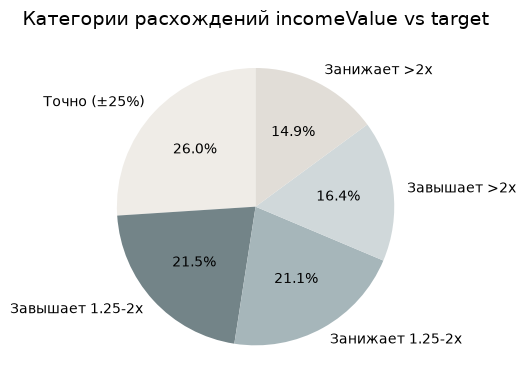

In [19]:
# АНАЛИЗ РАСХОЖДЕНИЙ (ГДЕ incomeValue ЗАВЫШАЕТ/ЗАНИЖАЕТ)
mask_both = (~train['incomeValue'].isna()) & (~train['target'].isna())
TRAIN_temp = train.loc[mask_both].copy()

# Отношение incomeValue к target
TRAIN_temp['income_to_target_ratio'] = TRAIN_temp['incomeValue'] / (TRAIN_temp['target'] + 1)

# Категории расхождений
def categorize_discrepancy(ratio):
    if ratio < 0.5:
        return 'Занижает >2x'
    elif ratio < 0.8:
        return 'Занижает 1.25-2x'
    elif ratio < 1.25:
        return 'Точно (±25%)'
    elif ratio < 2:
        return 'Завышает 1.25-2x'
    else:
        return 'Завышает >2x'

TRAIN_temp['discrepancy_category'] = TRAIN_temp['income_to_target_ratio'].apply(categorize_discrepancy)

# Визуализация распределения расхождений
fig, axes = plt.subplots(1, 1, figsize=(12, 4))

# Pie chart категорий
discrepancy_counts = TRAIN_temp['discrepancy_category'].value_counts()
axes.pie(
    discrepancy_counts,
    labels=discrepancy_counts.index,
    autopct='%1.1f%%',
    startangle=90, 
    colors= ['#EFECE7', '#738488', 
             '#A6B6BA', '#D0D8DA', '#E1DDD7']
)
axes.set_title('Категории расхождений incomeValue vs target', fontsize=14)

plt.tight_layout()
plt.show()

__Вывод__
****************
Сильным признаком является salary_6to12m_avg, во многих случаях совпадает с таргетом, однако в данном признаке 80% пропусков. В то же время есть признак incomeValue - это оценка заработной платы, полученная от телеком компании. Она очень неточная. 

В таком случае есть смысл сегментировать клиентов на 2 подгруппы: клиенты, у которых есть признак salary_6to12m_avg, и клиенты, у которых его нет
***************

# WMAE

In [19]:
# ФУНКЦИЯ ДЛЯ РАСЧЕТА МЕТРИКИ 

from sklearn.metrics import mean_absolute_error
def WMAE(y_true, y_pred, weights):
    return mean_absolute_error(y_true, y_pred, sample_weight = weights)

# Baseline-решение - Линейная регрессия

In [21]:
X = train_clean.drop(['target', 'w', 'dt', 'id', 'has_salary_6to12m_data', 'has_dp', 'has_bki'], axis = 1)
y = train_clean['target']
w = train_clean['w']

from sklearn.model_selection import KFold

# Разделяем признаки по типам для корректной предобработки
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['str', 'category']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ], verbose_feature_names_out=False)
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

X_train, X_val, y_train, y_val, w_train, w_val = train_test_split(X, y, w, 
                                                                  test_size=0.2, 
                                                                  random_state=42)
ridge_pipeline.fit(X_train, y_train)

alphas = np.logspace(-1, 4, 20)
cv_scores = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Начинаем подбор гиперпараметра alpha...")
for alpha in alphas:
    ridge_pipeline.set_params(regressor__alpha=alpha)
    fold_scores = []
    for train_idx, val_idx in kf.split(X_train):
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        w_fold_val = w_train.iloc[val_idx] 
        ridge_pipeline.fit(X_fold_train, y_fold_train)
        y_fold_pred = ridge_pipeline.predict(X_fold_val)
        score = WMAE(y_fold_val, y_fold_pred, w_fold_val)
        fold_scores.append(score)
    cv_scores.append(np.mean(fold_scores))


best_alpha = alphas[np.argmin(cv_scores)]
best_wmae = np.min(cv_scores)
print(f"Лучшее значение alpha: {best_alpha:.2f} (CV WMAE: {best_wmae:.2f})")


Начинаем подбор гиперпараметра alpha...
Лучшее значение alpha: 1623.78 (CV WMAE: 79361.78)


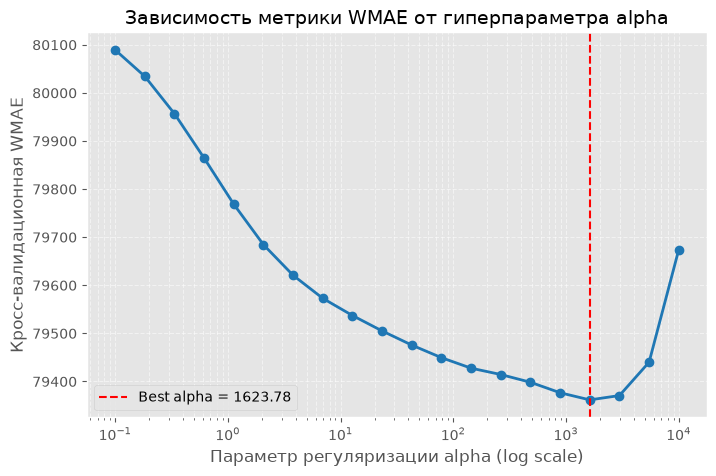

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(alphas, cv_scores, marker='o', linestyle='-', color='#1f77b4', linewidth=2)
plt.xscale('log')
plt.xlabel('Параметр регуляризации alpha (log scale)', fontsize=12)
plt.ylabel('Кросс-валидационная WMAE', fontsize=12)
plt.title('Зависимость метрики WMAE от гиперпараметра alpha', fontsize=14)
plt.axvline(best_alpha, color='red', linestyle='--', label=f'Best alpha = {best_alpha:.2f}')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

In [23]:
ridge_pipeline.set_params(regressor__alpha=best_alpha)
ridge_pipeline.fit(X_train, y_train)

y_pred = ridge_pipeline.predict(X_val)
baseline_WMAE = WMAE(y_val, y_pred, w_val)

print(f'\nИтоговый Baseline-WMAE (на валидационной выборке): {baseline_WMAE:.2f}')


Итоговый Baseline-WMAE (на валидационной выборке): 83128.98


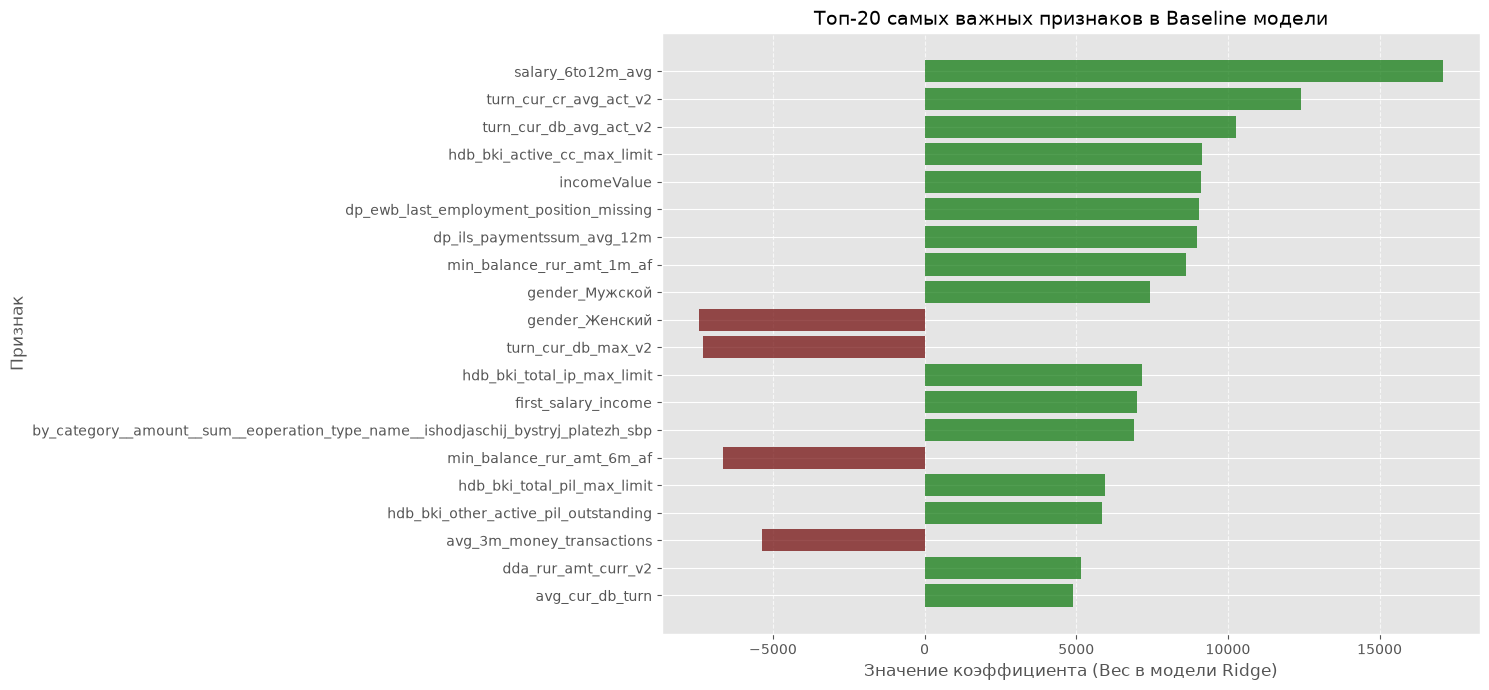

In [24]:
#  АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ

preprocessor_step = ridge_pipeline.named_steps['preprocessor']
model_step = ridge_pipeline.named_steps['regressor']
feature_names = preprocessor_step.get_feature_names_out()
coefficients = model_step.coef_
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})

top_features = feature_importance.sort_values(by='Abs_Coefficient', ascending=False).head(20)

plt.figure(figsize=(15, 7))
colors = ["#0c780cb8" if coef > 0 else "#700808B7" for coef in top_features['Coefficient']]
plt.barh(top_features['Feature'][::-1], top_features['Coefficient'][::-1], color=colors[::-1])

plt.xlabel('Значение коэффициента (Вес в модели Ridge)', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.title('Топ-20 самых важных признаков в Baseline модели', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [25]:
def plot_actual_vs_predicted(y_true, y_pred, weights=None, title="Анализ прогноза"):
    plt.figure(figsize=(8, 5))

    sizes = (weights * 50) if weights is not None else 30
    plt.scatter(y_true, y_pred, s=sizes, alpha=0.2, color='#0072C6', label='Клиенты (размер = вес)')
    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], '--', color = "#5407CE", linewidth=2, label='Идеальный прогноз (Факт = Прогноз)')
    plt.xlabel('Фактический доход (Actual)', fontsize=12)
    plt.ylabel('Прогноз модели (Predicted)', fontsize=12)
    plt.title(title, fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper left')
    plt.xlim(min_val * 0.9, max_val * 1.05)
    plt.ylim(min_val * 0.9, max_val * 1.05)
    plt.show()

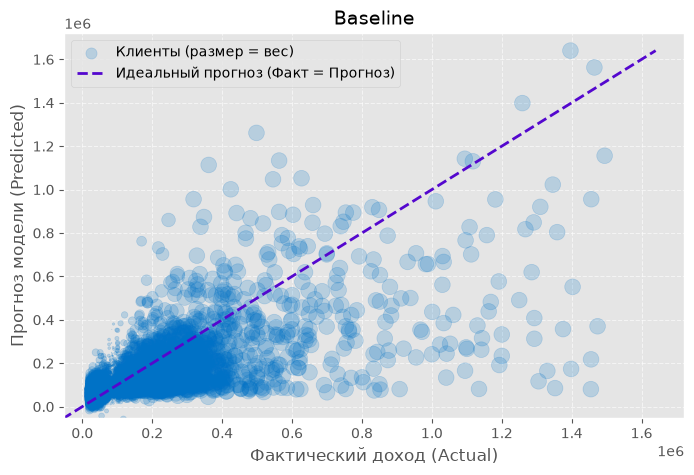

In [26]:
plot_actual_vs_predicted(y_val, y_pred, weights=w_val, title="Baseline")

In [27]:
def evaluate_wmae_by_bucket(
    y, w, preds, 
    sample_name="Выборка", 
    q=5
):    
    df_res = pd.DataFrame({
        'actual': y, 
        'pred': preds, 
        'weight': w,
        'abs_err': np.abs(y - preds)
    })

    if q == 5:
        labels = ['0-20% (Низкий)', '20-40% (Ниже среднего)', '40-60% (Средний)', '60-80% (Выше среднего)', '80-100% (Высокий)']
    else:
        labels = [f'Квантиль {i+1}' for i in range(q)]

    df_res['bucket'] = pd.qcut(df_res['actual'], q=q, labels=labels, duplicates='drop')

    def group_wmae(group):
        weight_sum = np.sum(group['weight'])
        if weight_sum == 0: 
            return 0
        return np.sum(group['abs_err'] * group['weight']) / weight_sum

    bucket_wmae = df_res.groupby('bucket', observed=False).apply(group_wmae).reset_index(name='WMAE')

    total_wmae = np.sum(df_res['abs_err'] * df_res['weight']) / np.sum(df_res['weight'])

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        x='bucket', 
        y='WMAE', 
        data=bucket_wmae, 
        palette='Blues_d'
    )
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f"{height:,.0f}", (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', xytext=(0, 8), textcoords='offset points', 
                        fontsize=10, fontweight='bold')

    plt.title(f'Ошибка модели по сегментам дохода:\nОбщий WMAE: {total_wmae:.2f}', 
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Группы клиентов по фактическому доходу', fontsize=12, labelpad=10)
    plt.ylabel('Взвешенный WMAE внутри группы', fontsize=12)
    # plt.ylim(0, bucket_wmae['WMAE'].max() * 1.15) 
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return total_wmae, bucket_wmae

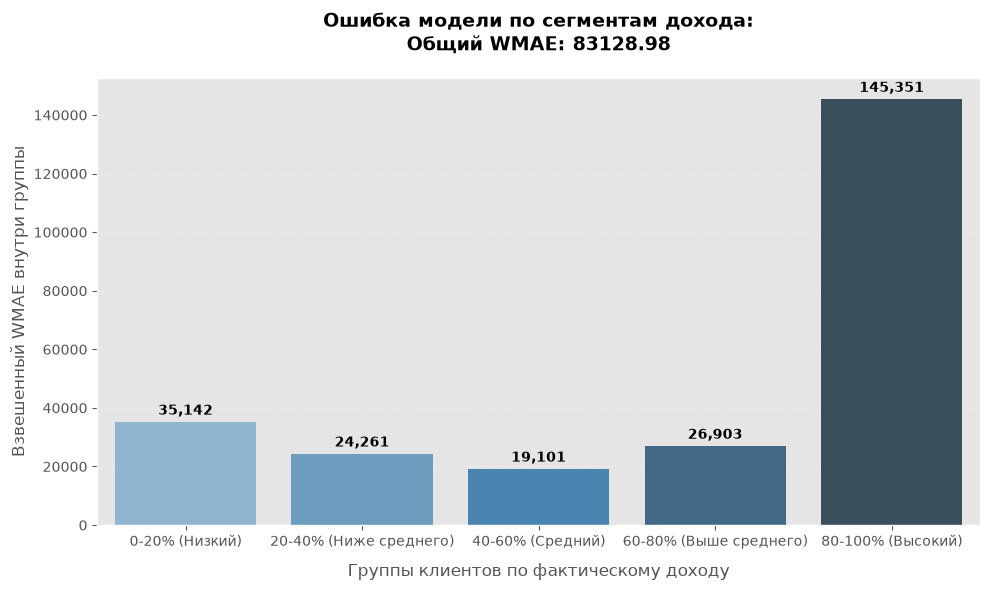

In [28]:

total_score, df_metrics = evaluate_wmae_by_bucket(
    y_val, w_val, y_pred, sample_name = "Baseline", q=5
)

# Сегментация по наличию данных

# Сегмент 1 - клиенты с заработной платой

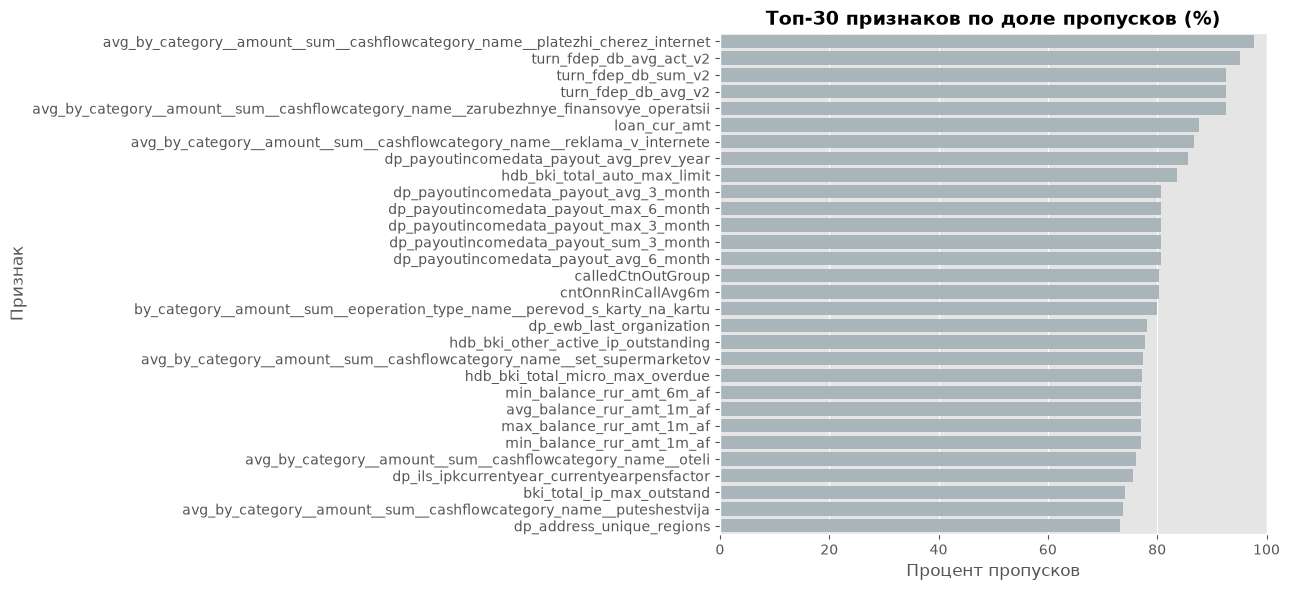

In [29]:
train1 = train_clean[train_clean['salary_6to12m_avg'].notna()]

features['miss%'] = train1.isnull().sum() / train1.shape[0] * 100
miss = features[features['miss%'] > 0].sort_values(by = 'miss%', ascending = False)
miss.head(5)

plt.figure(figsize=(13, 6))
sns.barplot(data= miss.head(30), x='miss%', y = miss.head(30).index, color = "#A6B6BA")
plt.title('Топ-30 признаков по доле пропусков (%)', fontsize = 14, fontweight = 'bold')
plt.xlabel('Процент пропусков')
plt.ylabel('Признак')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

### Генерация признаков

In [20]:
def create_features_group_with_salary(df: pd.DataFrame) -> tuple:
    """Генерация признаков для сегмента клиентов с известной зарплатой."""
    res_df = df.copy()
    custom_cols = []
    EPS = 1.0
    
    # 1. Отношение реального кредитового оборота к официальной ЗП (Поиск скрытого дохода)
    if "turn_cur_cr_avg_act_v2" in res_df.columns and "dp_ils_avg_salary_1y" in res_df.columns:
        res_df["real_vs_official_income_ratio"] = res_df["turn_cur_cr_avg_act_v2"] / (res_df["dp_ils_avg_salary_1y"] + EPS)
        custom_cols.append("real_vs_official_income_ratio")

    # 2. Отношение трат (дебет) к официальной ЗП
    if "turn_cur_db_avg_act_v2" in res_df.columns and "dp_ils_avg_salary_1y" in res_df.columns:
        res_df["spend_vs_official_income_ratio"] = res_df["turn_cur_db_avg_act_v2"] / (res_df["dp_ils_avg_salary_1y"] + EPS)
        custom_cols.append("spend_vs_official_income_ratio")

    # 3. Доверие банков (Лимит к официальной ЗП)
    if "hdb_bki_total_max_limit" in res_df.columns and "dp_ils_avg_salary_1y" in res_df.columns:
        res_df["limit_to_income_ratio"] = res_df["hdb_bki_total_max_limit"] / (res_df["dp_ils_avg_salary_1y"] + EPS)
        custom_cols.append("limit_to_income_ratio")

    # 4. Динамика официальной зарплаты (Текущая средняя минус первая зарплата)
    if "salary_6to12m_avg" in res_df.columns and "first_salary_income" in res_df.columns:
        res_df["salary_growth"] = res_df["salary_6to12m_avg"] - res_df["first_salary_income"]
        custom_cols.append("salary_growth")
        
    # 5. Динамика зарплаты за 2 года
    if "dp_ils_avg_salary_1y" in res_df.columns and "dp_ils_avg_salary_2y" in res_df.columns:
        res_df["dp_salary_growth_2y"] = res_df["dp_ils_avg_salary_1y"] - res_df["dp_ils_avg_salary_2y"]
        custom_cols.append("dp_salary_growth_2y")

    # 6. Базовые транзакционные балансы
    if "turn_cur_cr_avg_act_v2" in res_df.columns and "turn_cur_db_avg_act_v2" in res_df.columns:
        res_df["cr_db_ratio_avg"] = res_df["turn_cur_cr_avg_act_v2"] / (res_df["turn_cur_db_avg_act_v2"] + EPS)
        res_df["turnover_balance"] = res_df["turn_cur_cr_avg_act_v2"] - res_df["turn_cur_db_avg_act_v2"]
        res_df["savings_rate"] = res_df["turnover_balance"] / (res_df["turn_cur_cr_avg_act_v2"] + EPS)
        custom_cols.extend(["cr_db_ratio_avg", "turnover_balance", "savings_rate"])

    # 7. Тренд активных поступлений к историческим средним
    if "turn_cur_cr_avg_act_v2" in res_df.columns and "turn_cur_cr_avg_v2" in res_df.columns:
        res_df["trend_cr_active_vs_avg"] = res_df["turn_cur_cr_avg_act_v2"] / (res_df["turn_cur_cr_avg_v2"] + EPS)
        custom_cols.append("trend_cr_active_vs_avg")

    return res_df, custom_cols

##### Формирование выборки

In [21]:
mask_train_has = (train_clean["has_salary_6to12m_data"] == 1)
mask_test_has  = (test_clean["has_salary_6to12m_data"] == 1)
print(f"Объем выборки (С зарплатой): Train={train_clean[mask_train_has].shape[0]} | Test={test_clean[mask_test_has].shape[0]}")

df_group_has_train, custom_cols_has = create_features_group_with_salary(train_clean[mask_train_has])
df_group_has_test, _ = create_features_group_with_salary(test_clean[mask_test_has])
features_group_has = list(set(base_features_list + custom_cols_has))

y_has_full  = df_group_has_train['target'].values
w_has_full  = df_group_has_train['w'].values
dt_has_full = df_group_has_train['dt'].values

Объем выборки (С зарплатой): Train=14875 | Test=7634


##### Кодировка категориальных переменных

In [22]:
from sklearn.preprocessing import TargetEncoder

def encode_target_features_simplified(train_df, test_df, features_list, cat_columns, y_train):
    X_train_raw = train_df[features_list].copy()
    X_test_raw = test_df[features_list].copy()
    
    existing_cat = [c for c in cat_columns if c in X_train_raw.columns]
    
    if existing_cat:
        encoder = TargetEncoder(smooth="auto", cv=5, random_state=42)
        X_train_raw[existing_cat] = encoder.fit_transform(X_train_raw[existing_cat], y_train)
        X_test_raw[existing_cat] = encoder.transform(X_test_raw[existing_cat])
        
    return X_train_raw, X_test_raw

X_has_train_encoded, X_has_test_encoded = encode_target_features_simplified(
    df_group_has_train, df_group_has_test, features_group_has, CATEGORICAL_FEATURES, y_has_full
)

In [23]:
def audit_data(df: pd.DataFrame, dataset_name="Dataset"):
    print(f"=== АУДИТ ДАННЫХ ДЛЯ: {dataset_name} ===")
    print(f"Формат: {df.shape[0]} строк, {df.shape[1]} признаков")
    
    object_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
    if object_cols:
        print(f"Найдено {len(object_cols)} object-колонок")
        print(f"Примеры: {object_cols[:5]}")
    else:
        print("Текстовых колонок (object) нет. Все типы валидны")
        
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    inf_cols = [col for col in numeric_cols if np.isinf(df[col]).any()]
    if inf_cols:
        print(f"ВНИМАНИЕ: Найдено {len(inf_cols)} колонок с Inf!")
    else:
        print("Бесконечностей (Inf) не обнаружено.")

audit_data(X_has_train_encoded, "X_has_cv (С зарплатой - Обучение)")

=== АУДИТ ДАННЫХ ДЛЯ: X_has_cv (С зарплатой - Обучение) ===
Формат: 14875 строк, 229 признаков
Текстовых колонок (object) нет. Все типы валидны
Бесконечностей (Inf) не обнаружено.


#### Подбор гиперпараметров

In [ ]:
# from sklearn.model_selection import TimeSeriesSplit
# import json

# def xgb_temporal_cv_objective_salary(trial, X, y, w, dt_series):
#     params = {
#         "objective": "reg:absoluteerror",
#         "eval_metric": "mae",
#         "device": "cuda",
#         "tree_method": "hist",
#         "random_state": 42,
        
#         'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.06, log=True),
#         'max_depth': trial.suggest_int('max_depth', 5, 9), 
#         'subsample': trial.suggest_float('subsample', 0.7, 0.95),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
#         'reg_alpha': trial.suggest_float('reg_alpha', 0.5, 50.0, log=True), 
#         'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 50.0, log=True),
#         'min_child_weight': trial.suggest_int('min_child_weight', 5, 80, log=True) 
        
#     }
        
#     sort_idx = np.argsort(dt_series)
#     X_sorted = X.iloc[sort_idx].reset_index(drop=True)
#     y_sorted = y[sort_idx]
#     w_sorted = w[sort_idx]

#     tscv = TimeSeriesSplit(n_splits=4)
#     cv_scores = []

#     for fold, (train_idx, val_idx) in enumerate(tscv.split(X_sorted)):
#         window_size = 40_000
#         actual_train_idx = train_idx[-window_size:] if len(train_idx) > window_size else train_idx

#         X_train, X_val = X_sorted.iloc[actual_train_idx], X_sorted.iloc[val_idx]  
#         y_train, y_val = y_sorted[actual_train_idx], y_sorted[val_idx]  
#         w_train, w_val = w_sorted[actual_train_idx], w_sorted[val_idx]  
        
#         model = xgb.XGBRegressor(**params, n_estimators = 3000, early_stopping_rounds = 300)
#         model.fit(
#             X_train, y_train, sample_weight=w_train,
#             eval_set=[(X_val, y_val)], sample_weight_eval_set=[w_val],
#             verbose=False
#         )

#         preds = model.predict(X_val)
#         wmae = np.sum(w_val * np.abs(y_val - preds)) / np.sum(w_val)
#         cv_scores.append(wmae)
    
#     trial.set_user_attr('cv_scores', cv_scores)
    
#     return np.mean(cv_scores)

# def run_optuna_temporal_salary(X, y, w, dt_series, n_trials=10):
#     print("\nOptuna для группы: С зарплатой...")
#     study = optuna.create_study(direction="minimize", 
#                                 sampler=optuna.samplers.TPESampler(seed=42, multivariate=True))
#     study.optimize(lambda trial: xgb_temporal_cv_objective_salary(trial, X, y, w, dt_series), 
#                    n_trials=n_trials, show_progress_bar=True)

#     filename = "best_params_temporal_with_salary.json"
#     with open(filename, "w") as f:
#         json.dump(study.best_params, f, indent=4)
        
#     print(f"Лучший CV WMAE: {study.best_value:.4f}")
#     return study

In [ ]:
# study_has = run_optuna_temporal_salary(X_has_train_encoded, y_has_full, w_has_full, dt_has_full, n_trials=30)

c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-07-14 01:17:26,816] A new study created in memory with name: no-name-8db6ea48-52b2-46e7-9825-12efaf22eaf2



Optuna для группы: С зарплатой...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-07-14 01:18:16,560] Trial 0 finished with value: 28033.279644665836 and parameters: {'learning_rate': 0.012681384672778809, 'max_depth': 9, 'subsample': 0.8829984854528512, 'colsample_bytree': 0.779597545259111, 'reg_alpha': 1.0256691315437247, 'reg_lambda': 1.0255552094216984, 'min_child_weight': 5}. Best is trial 0 with value: 28033.279644665836.
[I 2026-07-14 01:19:02,699] Trial 1 finished with value: 29685.20945925436 and parameters: {'learning_rate': 0.04302600829668218, 'max_depth': 8, 'subsample': 0.8770181444490113, 'colsample_bytree': 0.6061753482887408, 'reg_alpha': 43.53010439152424, 'reg_lambda': 23.11294500510413, 'min_child_weight': 8}. Best is trial 0 with value: 28033.279644665836.
[I 2026-07-14 01:19:39,994] Trial 2 finished with value: 27535.13056874194 and parameters: {'learning_rate': 0.007855830402514549, 'max_depth': 5, 'subsample': 0.7760605607398844, 'colsample_bytree': 0.7574269294896714, 'reg_alpha': 3.6547699179564543, 'reg_lambda': 1.9117376123375922

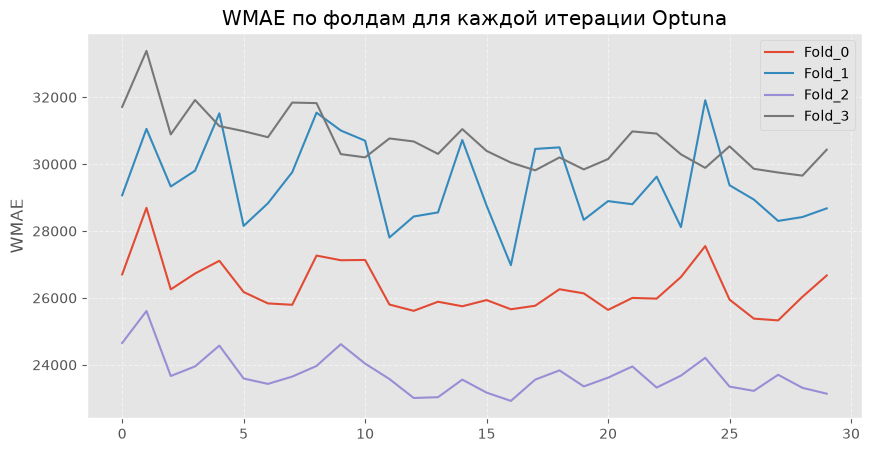

In [ ]:
# df_trials = study_has.trials_dataframe()
# fold_metrics = pd.DataFrame(
#     df_trials['user_attrs_cv_scores'].tolist(), 
#     columns=['Fold_0', 'Fold_1', 'Fold_2', 'Fold_3']
# )
# fold_metrics['Mean_WMAE'] = df_trials['value']
# fold_metrics['Trial_Number'] = df_trials['number']

# fold_metrics[['Fold_0', 'Fold_1', 'Fold_2', 'Fold_3']].plot(figsize=(10, 5), title='WMAE по фолдам для каждой итерации Optuna')
# plt.ylabel('WMAE')
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.show()

In [ ]:
# print("\n" + "="*40)
# print(f"Лучший Средний WMAE на OOT-валидации: {study_has.best_value:.4f}")
# print("Лучшие параметры для XGBoost:")
# for key, value in study_has.best_params.items():
#     print(f"  {key}: {value}")
# print("="*40)


Лучший Средний WMAE на OOT-валидации: 26402.3350
Лучшие параметры для XGBoost:
  learning_rate: 0.008847753460251205
  max_depth: 6
  subsample: 0.9314721229783923
  colsample_bytree: 0.8724347632567044
  reg_alpha: 6.397371754513276
  reg_lambda: 5.153833965419557
  min_child_weight: 32


#### Визуализация

In [ ]:
# import optuna.visualization as vis
# import plotly.io as pio
# def visualize_optuna_results(study):
#     # 1. История оптимизации
#     fig1 = vis.plot_optimization_history(study)
#     fig1.update_layout(title='История оптимизации', height=400, width=700)
#     fig1.show()
#     # 2. Важность гиперпараметров
#     fig2 = vis.plot_param_importances(study)
#     fig2.update_layout(title='Важность гиперпараметров', height=400, width=700)
#     fig2.show()
# visualize_optuna_results(study_has)

#### Финальное обучение модели

In [24]:
import os
import json

def load_model_params(file_path: str) -> dict:
    try:
        with open(file_path, 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        print(f"Файл '{file_path}' не найден! Используются дефолтные параметры.")
        return {}

params_has = load_model_params('best_params_temporal_with_salary.json')
base_config = {
    'objective': 'reg:absoluteerror', 
    'eval_metric': 'mae', 
    'device': 'cuda', 
    'tree_method': 'hist', 
    'random_state': 42
}

In [25]:
model_has_salary = xgb.XGBRegressor(**{**base_config, **params_has, 'seed': 42}, n_estimators=1200)
model_has_salary.fit(X_has_train_encoded, y_has_full, 
                     sample_weight=w_has_full,
                     eval_set=[(X_has_train_encoded, y_has_full)],
                     sample_weight_eval_set=[w_has_full], 
                     verbose=200)

[0]	validation_0-mae:155207.32334
[200]	validation_0-mae:26689.98130
[400]	validation_0-mae:21329.65835
[600]	validation_0-mae:18458.48987
[800]	validation_0-mae:17015.66841
[1000]	validation_0-mae:16295.32448
[1199]	validation_0-mae:15746.34026


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:absoluteerror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8254610219325117
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets impo

# Сегмент 2

In [26]:
# 2. Группа В (Цифровой профиль): есть ЦП, зарплата может быть, а может и нет
mask_train_dp = (train_clean["has_dp"] == 1)
mask_test_dp  = (test_clean["has_dp"] == 1)

##### Генерация признаков

In [27]:
def create_features_group_digital_profile(df: pd.DataFrame) -> tuple:
    """Генерация признаков для сегмента клиентов с цифровым профилем."""
    res_df = df.copy()
    custom_cols = []
    EPS = 1e-5
    
    # 1. Счетчик заполненности цифрового профиля
    dp_cols = [c for c in res_df.columns if c.startswith('dp_')]
    if dp_cols:
        res_df['dp_profile_completeness'] = res_df[dp_cols].notna().sum(axis=1)
        custom_cols.append('dp_profile_completeness')

    # 2. Динамика и тренды официальной зарплаты
    if "dp_ils_avg_salary_1y" in res_df.columns and "dp_ils_avg_salary_2y" in res_df.columns:
        res_df["dp_salary_growth_2y"] = res_df["dp_ils_avg_salary_1y"] - res_df["dp_ils_avg_salary_2y"]
        res_df["dp_salary_trend_1y_2y"] = res_df["dp_ils_avg_salary_1y"] / (res_df["dp_ils_avg_salary_2y"] + EPS)
        custom_cols.extend(["dp_salary_growth_2y", "dp_salary_trend_1y_2y"])
        
    if "dp_ils_avg_salary_2y" in res_df.columns and "dp_ils_avg_salary_3y" in res_df.columns:
        res_df["dp_salary_trend_2y_3y"] = res_df["dp_ils_avg_salary_2y"] / (res_df["dp_ils_avg_salary_3y"] + EPS)
        custom_cols.append("dp_salary_trend_2y_3y")

    # 3. Стабильность занятости и "карьерные" маркеры
    if "dp_ils_total_seniority" in res_df.columns and "dp_ils_uniq_companies_1y" in res_df.columns:
        res_df['dp_seniority_per_employer'] = res_df['dp_ils_total_seniority'] / (res_df['dp_ils_uniq_companies_1y'] + 1)
        custom_cols.append('dp_seniority_per_employer')
        
    if "dp_ils_max_seniority" in res_df.columns and "dp_ils_total_seniority" in res_df.columns:
        res_df['dp_max_seniority_share'] = res_df['dp_ils_max_seniority'] / (res_df['dp_ils_total_seniority'] + EPS)
        custom_cols.append('dp_max_seniority_share')
        
    if "dp_ewb_dismissal_due_contract_violation_by_lb_cnt" in res_df.columns:
        res_df['dp_has_contract_violation'] = (res_df['dp_ewb_dismissal_due_contract_violation_by_lb_cnt'] > 0).astype(int)
        custom_cols.append('dp_has_contract_violation')

    # 4. Профиль выплат и социальных поступлений (По волатильности)
    if "dp_ils_paymentssum_avg_6m" in res_df.columns and "dp_ils_paymentssum_avg_12m" in res_df.columns:
        res_df['dp_payout_velocity_6m_12m'] = res_df['dp_ils_paymentssum_avg_6m'] / (res_df['dp_ils_paymentssum_avg_12m'] + EPS)
        custom_cols.append('dp_payout_velocity_6m_12m')
        
    if "dp_ils_paymentssum_month_avg" in res_df.columns and "dp_ils_avg_salary_1y" in res_df.columns:
        res_df['dp_payout_to_salary_ratio'] = res_df['dp_ils_paymentssum_month_avg'] / (res_df['dp_ils_avg_salary_1y'] + EPS)
        custom_cols.append('dp_payout_to_salary_ratio')

    if "dp_payoutincomedata_payout_max_3_month" in res_df.columns and "dp_payoutincomedata_payout_avg_3_month" in res_df.columns:
        res_df['dp_payout_stability_3m'] = res_df['dp_payoutincomedata_payout_max_3_month'] - res_df['dp_payoutincomedata_payout_avg_3_month']
        custom_cols.append('dp_payout_stability_3m')

    # 5. Синергетические признаки
    if "turn_cur_cr_avg_v2" in res_df.columns and "dp_ils_avg_salary_1y" in res_df.columns:
        res_df['bank_turn_to_dp_salary_ratio'] = res_df['turn_cur_cr_avg_v2'] / (res_df['dp_ils_avg_salary_1y'] + EPS)
        custom_cols.append('bank_turn_to_dp_salary_ratio')
        
    if "avg_by_category__amount__sum__cashflowcategory_name__supermarkety" in res_df.columns and "dp_ils_avg_salary_1y" in res_df.columns:
        res_df['supermarket_to_dp_salary_ratio'] = res_df['avg_by_category__amount__sum__cashflowcategory_name__supermarkety'] / (res_df['dp_ils_avg_salary_1y'] + EPS)
        custom_cols.append('supermarket_to_dp_salary_ratio')

    # ИНТЕГРАЦИЯ БКИ-ФИЧ: Добавляем ключевые инсайты БКИ для клиентов с ЦП
    if "hdb_bki_total_max_limit" in res_df.columns:
        if "hdb_outstand_sum" in res_df.columns:
            res_df["dp_bki_global_utilization"] = res_df["hdb_outstand_sum"] / (res_df["hdb_bki_total_max_limit"] + EPS)
            custom_cols.append("dp_bki_global_utilization")
        if "hdb_ovrd_sum" in res_df.columns:
            res_df["dp_bki_overdue_to_outstanding"] = res_df["hdb_ovrd_sum"] / (res_df["hdb_outstand_sum"].fillna(0) + 1.0)
            custom_cols.append("dp_bki_overdue_to_outstanding")

    return res_df, custom_cols

In [28]:
# Модель В (С цифровым профилем — обогащена ключевыми БКИ инсайтами)
df_group_dp_train, custom_cols_dp = create_features_group_digital_profile(train_clean[mask_train_dp])
df_group_dp_test, _ = create_features_group_digital_profile(test_clean[mask_test_dp])
features_group_dp = list(set(base_features_list + custom_cols_dp))

In [29]:
# Целевая переменная сохраняется строго в исходном виде
y_dp_full   = df_group_dp_train['target'].values
w_dp_full   = df_group_dp_train['w'].values
dt_dp_full  = df_group_dp_train['dt'].values

#### Кодировка категориальных признаков

In [30]:
# 5.2 Кодируем группу "С Цифровым Профилем" (Модель В)
X_dp_train_encoded, X_dp_test_encoded = encode_target_features_simplified(
    df_group_dp_train, df_group_dp_test, features_group_dp, CATEGORICAL_FEATURES, y_dp_full
)

In [31]:
audit_data(X_dp_train_encoded, "X_dp_cv (С Цифровым Профилем - Обучение)")

=== АУДИТ ДАННЫХ ДЛЯ: X_dp_cv (С Цифровым Профилем - Обучение) ===
Формат: 16683 строк, 234 признаков
Текстовых колонок (object) нет. Все типы валидны
Бесконечностей (Inf) не обнаружено.


##### Подбор гиперапараметров

In [ ]:
# def xgb_temporal_cv_objective_dp(trial, X, y, w, dt_series):
#     params = {
#         "objective": "reg:absoluteerror",
#         "eval_metric": "mae",
#         "device": "cuda",
#         "tree_method": "hist",
#         "random_state": 42,
        
#         'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
#         'max_depth': trial.suggest_int('max_depth', 4, 8), 
#         'subsample': trial.suggest_float('subsample', 0.7, 0.9),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.8),
#         'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 30.0, log=True), 
#         'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 30.0, log=True),
#         'min_child_weight': trial.suggest_int('min_child_weight', 10, 100, log=True) 
#     }

#     sort_idx = np.argsort(dt_series)
#     X_sorted = X.iloc[sort_idx].reset_index(drop=True)
#     y_sorted = y[sort_idx]
#     w_sorted = w[sort_idx]

#     tscv = TimeSeriesSplit(n_splits=4)
#     cv_scores = []

#     for fold, (train_idx, val_idx) in enumerate(tscv.split(X_sorted)):
#         window_size = 40000
#         actual_train_idx = train_idx[-window_size:] if len(train_idx) > window_size else train_idx

#         X_train, X_val = X_sorted.iloc[actual_train_idx], X_sorted.iloc[val_idx]  
#         y_train, y_val = y_sorted[actual_train_idx], y_sorted[val_idx]  
#         w_train, w_val = w_sorted[actual_train_idx], w_sorted[val_idx]  

#         model = xgb.XGBRegressor(**params, n_estimators=5000, early_stopping_rounds=300)
#         model.fit(
#             X_train, y_train, sample_weight=w_train,
#             eval_set=[(X_val, y_val)], sample_weight_eval_set=[w_val],
#             verbose=False
#         )

#         preds = model.predict(X_val)
#         wmae = np.sum(w_val * np.abs(y_val - preds)) / np.sum(w_val)
#         cv_scores.append(wmae)

#     return np.mean(cv_scores)

# def run_optuna_temporal_dp(X, y, w, dt_series, n_trials=10):
#     print("\nOptuna для группы: С цифровым профилем...")
#     study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42, multivariate=True))
#     study.optimize(lambda trial: xgb_temporal_cv_objective_dp(trial, X, y, w, dt_series), n_trials=n_trials, show_progress_bar=True)
    
#     filename = "best_params_temporal_digital_profile.json"
#     with open(filename, "w") as f:
#         json.dump(study.best_params, f, indent=4)
        
#     print(f"Успешно! Лучший CV WMAE: {study.best_value:.4f}")
#     return study

# study_dp = run_optuna_temporal_dp(X_dp_train_encoded, y_dp_full, w_dp_full, dt_dp_full, n_trials=30)

c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-07-14 01:56:33,887] A new study created in memory with name: no-name-2aece84c-c8a4-4bcb-b86c-fddf0bf56f49



Optuna для группы: С цифровым профилем...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-07-14 01:57:12,825] Trial 0 finished with value: 52385.914216443205 and parameters: {'learning_rate': 0.01184431975182039, 'max_depth': 8, 'subsample': 0.846398788362281, 'colsample_bytree': 0.7197316968394073, 'reg_alpha': 0.24348773534554594, 'reg_lambda': 0.24345423962016924, 'min_child_weight': 11}. Best is trial 0 with value: 52385.914216443205.
[I 2026-07-14 01:57:47,092] Trial 1 finished with value: 53951.66560737833 and parameters: {'learning_rate': 0.03674059202635224, 'max_depth': 7, 'subsample': 0.8416145155592091, 'colsample_bytree': 0.6041168988591604, 'reg_alpha': 25.26878207508456, 'reg_lambda': 11.536162338241391, 'min_child_weight': 16}. Best is trial 0 with value: 52385.914216443205.
[I 2026-07-14 01:58:33,413] Trial 2 finished with value: 54109.3398503925 and parameters: {'learning_rate': 0.007599674150654906, 'max_depth': 4, 'subsample': 0.7608484485919075, 'colsample_bytree': 0.7049512863264475, 'reg_alpha': 1.1748439548007035, 'reg_lambda': 0.5265139631677

In [ ]:
# print("\n" + "="*40)
# print(f"Лучший Средний WMAE на валидации: {study_dp.best_value:.4f}")
# print("Лучшие параметры для XGBoost:")
# for key, value in study_dp.best_params.items():
#     print(f"  {key}: {value}")
# print("="*40)


Лучший Средний WMAE на валидации: 51769.8390
Лучшие параметры для XGBoost:
  learning_rate: 0.0061748724800959965
  max_depth: 8
  subsample: 0.8605000642590014
  colsample_bytree: 0.7292886689085348
  reg_alpha: 2.4276248263739766
  reg_lambda: 0.11230005184134262
  min_child_weight: 11


#### Визуализация

In [ ]:
# visualize_optuna_results(study_dp)

#### Финальное обучение модели

In [32]:
params_dp = load_model_params('best_params_temporal_digital_profile.json')
base_config = {
    'objective': 'reg:absoluteerror', 
    'eval_metric': 'mae', 
    'device': 'cuda', 
    'tree_method': 'hist', 
    'random_state': 42
}

In [33]:
model_digital_profile = xgb.XGBRegressor(**{**base_config, **params_dp}, n_estimators=2000)
# model_digital_profile.fit(X_dp_train_encoded, y_dp_full, sample_weight=w_dp_full, verbose=200)

model_digital_profile.fit(X_dp_train_encoded, y_dp_full, 
                     sample_weight=w_dp_full,
                     eval_set=[(X_dp_train_encoded, y_dp_full)],
                     sample_weight_eval_set=[w_dp_full], 
                     verbose=200)

[0]	validation_0-mae:150811.67735
[200]	validation_0-mae:60437.67924
[400]	validation_0-mae:40138.44315
[600]	validation_0-mae:32353.06326
[800]	validation_0-mae:27807.66732
[1000]	validation_0-mae:25139.44811
[1200]	validation_0-mae:23246.24373
[1400]	validation_0-mae:21573.49433
[1600]	validation_0-mae:20195.81450
[1800]	validation_0-mae:19190.84265
[1999]	validation_0-mae:18390.09968


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:absoluteerror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7669045666174993
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets impo

# Сегмент 3

In [34]:
def create_features_group_no_salary(df: pd.DataFrame) -> tuple:
    """Генерация признаков для сегмента клиентов без официальной зарплаты (Обогащено БКИ-признаками)."""
    res_df = df.copy()
    custom_cols = []
    EPS = 1.0
        
    # 1. Логарифм транзакционного масштаба и соотношения кредита/дебета
    if "turn_cur_cr_avg_act_v2" in res_df.columns and "turn_cur_db_avg_act_v2" in res_df.columns:
        raw_turnover = (res_df["turn_cur_cr_avg_act_v2"].fillna(0) + res_df["turn_cur_db_avg_act_v2"].fillna(0)).clip(lower=0)
        res_df["log_total_turnover"] = np.log1p(raw_turnover)
        res_df["cr_db_ratio_avg"] = res_df["turn_cur_cr_avg_act_v2"] / (res_df["turn_cur_db_avg_act_v2"] + EPS)
        res_df["turnover_balance"] = res_df["turn_cur_cr_avg_act_v2"] - res_df["turn_cur_db_avg_act_v2"]
        custom_cols.extend(["log_total_turnover", "cr_db_ratio_avg", "turnover_balance"])

    # 2. Кредитная активность и маркеры богатства от БКИ (Базовые + Глубокая интеграция БКИ)
    if "hdb_bki_total_max_limit" in res_df.columns:
        res_df["is_zero_bki"] = res_df["hdb_bki_total_max_limit"].isna().astype(int)
        custom_cols.append("is_zero_bki")
        
        if "hdb_outstand_sum" in res_df.columns:
            res_df["utilization_global"] = res_df["hdb_outstand_sum"] / (res_df["hdb_bki_total_max_limit"] + EPS)
            custom_cols.append("utilization_global")
            
        if "hdb_bki_total_cc_max_limit" in res_df.columns:
            res_df["cc_limit_share"] = res_df["hdb_bki_total_cc_max_limit"] / (res_df["hdb_bki_total_max_limit"] + EPS)
            res_df["heavy_credit_limit"] = (res_df["hdb_bki_total_max_limit"].fillna(0) - res_df["hdb_bki_total_cc_max_limit"].fillna(0)).clip(lower=0)
            custom_cols.extend(["cc_limit_share", "heavy_credit_limit"])

    # --- БКИ ---
    
    # А. Счетчик заполненности блока БКИ (степень активности кредитной истории)
    bki_check_cols = [c for c in res_df.columns if c.startswith('hdb_bki_') or c.startswith('bki_')]
    if bki_check_cols:
        res_df['bki_data_completeness'] = res_df[bki_check_cols].notna().sum(axis=1)
        custom_cols.append('bki_data_completeness')

    # Б. Отношение максимального лимита IL (потреб. кредитов) к общему лимиту БКИ (Доля тяжелого долга)
    if "bki_total_il_max_limit" in res_df.columns and "hdb_bki_total_max_limit" in res_df.columns:
        res_df["bki_il_to_total_limit_ratio"] = res_df["bki_total_il_max_limit"] / (res_df["hdb_bki_total_max_limit"] + EPS)
        custom_cols.append("bki_il_to_total_limit_ratio")

    # В. Доля активных продуктов в общем количестве продуктов БКИ
    if "bki_total_active_products" in res_df.columns and "bki_total_products" in res_df.columns:
        res_df["bki_active_products_share"] = res_df["bki_total_active_products"] / (res_df["bki_total_products"] + EPS)
        custom_cols.append("bki_active_products_share")

    # Г. Общая просрочка относительно текущего долга (Маркер критического стресса)
    if "hdb_ovrd_sum" in res_df.columns and "hdb_outstand_sum" in res_df.columns:
        res_df["bki_overdue_to_outstanding_ratio"] = res_df["hdb_ovrd_sum"] / (res_df["hdb_outstand_sum"] + EPS)
        custom_cols.append("bki_overdue_to_outstanding_ratio")

    # Д. Отношение лимита кредитных карт к лимиту потребительских кредитов (Гибкий vs Фиксированный долг)
    if "hdb_bki_total_cc_max_limit" in res_df.columns and "bki_total_il_max_limit" in res_df.columns:
        res_df["bki_cc_to_il_limit_ratio"] = res_df["hdb_bki_total_cc_max_limit"] / (res_df["bki_total_il_max_limit"] + EPS)
        custom_cols.append("bki_cc_to_il_limit_ratio")

    # Е. Доля микрозаймов в общем пуле кредитов (Маркер высокорискового клиента)
    if "hdb_bki_total_micro_cnt" in res_df.columns and "bki_total_products" in res_df.columns:
        res_df["bki_micro_loans_share"] = res_df["hdb_bki_total_micro_cnt"] / (res_df["bki_total_products"] + EPS)
        custom_cols.append("bki_micro_loans_share")
        
    # --- КОНЕЦ БКИ ---

    # 3. Премиальное потребление (Заменитель высокого дохода)
    premium_spend_cols = [
        "avg_6m_hotels",
        "avg_6m_restaurants",
        "avg_by_category__amount__sum__cashflowcategory_name__zarubezhnye_finansovye_operatsii",
    ]
    if all(c in res_df.columns for c in premium_spend_cols) and "turn_cur_db_avg_v2" in res_df.columns:
        premium_sum = res_df[premium_spend_cols].fillna(0).sum(axis=1)
        res_df["premium_spend_share"] = premium_sum / (res_df["turn_cur_db_avg_v2"] + EPS)
        custom_cols.append("premium_spend_share")

    # 4. Индекс премиального лайфстайла
    if "avg_6m_hotels" in res_df.columns and "device_iphone_avg" in res_df.columns:
        hotels = res_df["avg_6m_hotels"].fillna(0).clip(lower=0)
        res_df["premium_lifestyle_index"] = np.log1p(hotels) * res_df["device_iphone_avg"].fillna(0)
        custom_cols.append("premium_lifestyle_index")

    # 5. Маркер бизнес-активности или фриланса
    sbp_out_col = "by_category__amount__sum__eoperation_type_name__ishodjaschij_bystryj_platezh_sbp"
    if sbp_out_col in res_df.columns and "turn_cur_db_avg_act_v2" in res_df.columns:
        res_df["sbp_out_share"] = res_df[sbp_out_col].fillna(0) / (res_df["turn_cur_db_avg_act_v2"] + EPS)
        custom_cols.append("sbp_out_share")

    # 6. Наличие инвестиционных приложений
    invest_apps = [
        "vert_has_app_ru_vtb_invest", 
        "vert_has_app_ru_cian_main", 
        "vert_has_app_ru_raiffeisennews", 
        "vert_has_app_ru_tinkoff_investing"
    ]
    if all(c in res_df.columns for c in invest_apps):
        res_df["has_any_investment_app"] = res_df[invest_apps].max(axis=1).fillna(0).astype(int)
        custom_cols.append("has_any_investment_app")

    # 7. Финансовый стресс / серая зона
    cash_col = "avg_by_category__amount__sum__cashflowcategory_name__vydacha_nalichnyh_v_bankomate"
    if cash_col in res_df.columns and "turn_cur_db_avg_act_v2" in res_df.columns:
        res_df["cash_withdrawal_share"] = res_df[cash_col].fillna(0) / (res_df["turn_cur_db_avg_act_v2"] + EPS)
        custom_cols.append("cash_withdrawal_share")

    return res_df, custom_cols

In [35]:
mask_train_no = (train_clean["has_salary_6to12m_data"] == 0)
mask_test_no  = (test_clean["has_salary_6to12m_data"] == 0)

# Модель Б (Без зарплаты — максимально усилена БКИ-метриками бывшей модели Г)
df_group_no_train, custom_cols_no = create_features_group_no_salary(train_clean[mask_train_no])
df_group_no_test, _ = create_features_group_no_salary(test_clean[mask_test_no])
features_group_no = list(set(base_features_list + custom_cols_no))

# Для Модели Б (Без зарплаты + БКИ фичи)
y_no_full   = df_group_no_train['target'].values
w_no_full   = df_group_no_train['w'].values
dt_no_full  = df_group_no_train['dt'].values

X_no_train_encoded, X_no_test_encoded = encode_target_features_simplified(
    df_group_no_train, df_group_no_test, features_group_no, CATEGORICAL_FEATURES, y_no_full
)

audit_data(X_no_train_encoded, "X_no_cv (Без зарплаты - Обучение)")

=== АУДИТ ДАННЫХ ДЛЯ: X_no_cv (Без зарплаты - Обучение) ===
Формат: 61911 строк, 238 признаков
Текстовых колонок (object) нет. Все типы валидны
Бесконечностей (Inf) не обнаружено.


In [ ]:
# def xgb_temporal_cv_objective_NO_DATA(trial, X, y, w, dt_series):
#     params = {
#         "objective": "reg:absoluteerror",
#         "eval_metric": "mae",
#         "device": "cuda",
#         "tree_method": "hist",
#         "random_state": 42,
        
#         'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.03, log=True),
#         'max_depth': trial.suggest_int('max_depth', 3, 5), 
#         'subsample': trial.suggest_float('subsample', 0.6, 0.8),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.7),
#         'reg_alpha': trial.suggest_float('reg_alpha', 10.0, 500.0, log=True), 
#         'reg_lambda': trial.suggest_float('reg_lambda', 10.0, 500.0, log=True),
#         'min_child_weight': trial.suggest_int('min_child_weight', 50, 500, log=True) 
#     }
        
#     sort_idx = np.argsort(dt_series)
#     X_sorted = X.iloc[sort_idx].reset_index(drop=True)
#     y_sorted = y[sort_idx]
#     w_sorted = w[sort_idx]

#     tscv = TimeSeriesSplit(n_splits=4)
#     cv_scores = []

#     for fold, (train_idx, val_idx) in enumerate(tscv.split(X_sorted)):
#         window_size = 40000
#         actual_train_idx = train_idx[-window_size:] if len(train_idx) > window_size else train_idx

#         X_train, X_val = X_sorted.iloc[actual_train_idx], X_sorted.iloc[val_idx]  
#         y_train, y_val = y_sorted[actual_train_idx], y_sorted[val_idx]  
#         w_train, w_val = w_sorted[actual_train_idx], w_sorted[val_idx]  

#         model = xgb.XGBRegressor(**params, n_estimators=10_000, early_stopping_rounds=500)
#         model.fit(
#             X_train, y_train, sample_weight=w_train,
#             eval_set=[(X_val, y_val)], sample_weight_eval_set=[w_val],
#             verbose=False
#         )

#         preds = model.predict(X_val)
#         wmae = np.sum(w_val * np.abs(y_val - preds)) / np.sum(w_val)
#         cv_scores.append(wmae)

#     return np.mean(cv_scores)

# def run_optuna_temporal_NO_DATA(X, y, w, dt_series, n_trials=10):
#     print("\nOptuna для группы: С цифровым профилем...")
#     study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42, multivariate=True))
#     study.optimize(lambda trial: xgb_temporal_cv_objective_NO_DATA(trial, X, y, w, dt_series), n_trials=n_trials, show_progress_bar=True)
    
#     filename = "best_params_temporal_with_NO_DATA.json"
#     with open(filename, "w") as f:
#         json.dump(study.best_params, f, indent=4)
        
#     print(f"Успешно! Лучший CV WMAE: {study.best_value:.4f}")
#     return study

# study_NO_DATA = run_optuna_temporal_NO_DATA(X_no_train_encoded, y_no_full, w_no_full, dt_no_full, n_trials=30)

c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-07-14 02:26:35,203] A new study created in memory with name: no-name-ebf73023-c7d2-447c-b0af-ac8ee2ba3c70



Optuna для группы: С цифровым профилем...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-07-14 02:28:11,184] Trial 0 finished with value: 69280.30142835889 and parameters: {'learning_rate': 0.009781801964118503, 'max_depth': 5, 'subsample': 0.746398788362281, 'colsample_bytree': 0.6197316968394073, 'reg_alpha': 18.410729205738683, 'reg_lambda': 18.408992080552522, 'min_child_weight': 57}. Best is trial 0 with value: 69280.30142835889.
[I 2026-07-14 02:28:43,009] Trial 1 finished with value: 81107.90894969547 and parameters: {'learning_rate': 0.023604024417191158, 'max_depth': 4, 'subsample': 0.7416145155592091, 'colsample_bytree': 0.5041168988591604, 'reg_alpha': 444.475416669081, 'reg_lambda': 259.59425503112647, 'min_child_weight': 81}. Best is trial 0 with value: 69280.30142835889.
[I 2026-07-14 02:30:45,051] Trial 2 finished with value: 71820.77951187766 and parameters: {'learning_rate': 0.006925598810528835, 'max_depth': 3, 'subsample': 0.6608484485919075, 'colsample_bytree': 0.6049512863264476, 'reg_alpha': 54.18282319533238, 'reg_lambda': 31.24565071260871, 

In [ ]:
# print("\n" + "="*40)
# print(f"Лучший Средний WMAE на валидации: {study_NO_DATA.best_value:.4f}")
# print("Лучшие параметры для XGBoost:")
# for key, value in study_NO_DATA.best_params.items():
#     print(f"  {key}: {value}")
# print("="*40)

# visualize_optuna_results(study_NO_DATA)


Лучший Средний WMAE на валидации: 69231.1300
Лучшие параметры для XGBoost:
  learning_rate: 0.011593053457091714
  max_depth: 5
  subsample: 0.741888019873681
  colsample_bytree: 0.6696965098162728
  reg_alpha: 12.157269854820111
  reg_lambda: 11.75090859194274
  min_child_weight: 52


In [36]:
params_no = load_model_params('best_params.json')
base_config = {
    'objective': 'reg:absoluteerror', 
    'eval_metric': 'mae', 
    'device': 'cuda', 
    'tree_method': 'hist', 
    'random_state': 42
}

In [37]:
model_no_salary = xgb.XGBRegressor(**{**base_config, **params_no}, n_estimators=30000)

model_no_salary.fit(X_no_train_encoded, y_no_full, 
                     sample_weight=w_no_full,
                     eval_set=[(X_no_train_encoded, y_no_full)],
                     sample_weight_eval_set=[w_no_full], 
                     verbose=200)

[0]	validation_0-mae:121291.89902
[200]	validation_0-mae:78964.03028
[400]	validation_0-mae:66123.92730
[600]	validation_0-mae:61048.85909
[800]	validation_0-mae:57418.17000
[1000]	validation_0-mae:54526.55307
[1200]	validation_0-mae:52235.27020
[1400]	validation_0-mae:50400.24445
[1600]	validation_0-mae:48878.52177
[1800]	validation_0-mae:47609.05748
[2000]	validation_0-mae:46504.40955
[2200]	validation_0-mae:45836.45106
[2400]	validation_0-mae:45181.82660
[2600]	validation_0-mae:44652.54060
[2800]	validation_0-mae:44226.33741
[3000]	validation_0-mae:43748.22750
[3200]	validation_0-mae:43279.53137
[3400]	validation_0-mae:42880.63220
[3600]	validation_0-mae:42501.13122
[3800]	validation_0-mae:42106.05654
[4000]	validation_0-mae:41781.97244
[4200]	validation_0-mae:41547.61713
[4400]	validation_0-mae:41380.90180
[4600]	validation_0-mae:41175.07713
[4800]	validation_0-mae:40915.58923
[5000]	validation_0-mae:40684.41723
[5200]	validation_0-mae:40404.58873
[5400]	validation_0-mae:40042.3581

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:absoluteerror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8795102054015881
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets impo

### Итоговое предсказание

In [38]:
print("\nГенерация предсказаний для тестовой выборки")

# Массив для накопления предсказаний моделей
test_preds_accumulator = np.zeros(len(test_clean))
models_count_accumulator = np.zeros(len(test_clean))

# Модели А 
if len(X_has_test_encoded) > 0:
    print(f"-> Модель А (С зарплатой) для N={len(X_has_test_encoded)} строк...")
    preds_has = model_has_salary.predict(X_has_test_encoded)
    test_preds_accumulator[mask_test_has] += preds_has
    models_count_accumulator[mask_test_has] += 1.0

# Модели В 
if len(X_dp_test_encoded) > 0:
    print(f"-> Модель В (Цифровой профиль) для N={len(X_dp_test_encoded)} строк...")
    preds_dp = model_digital_profile.predict(X_dp_test_encoded)
    test_preds_accumulator[mask_test_dp] += preds_dp
    models_count_accumulator[mask_test_dp] += 1.0

# Модели Б 
if len(X_no_test_encoded) > 0:
    print(f"-> Модель Б (Без зарплаты) для N={len(X_no_test_encoded)} строк...")
    preds_no = model_no_salary.predict(X_no_test_encoded)
    test_preds_accumulator[mask_test_no] += preds_no
    models_count_accumulator[mask_test_no] += 1.0

final_preds = np.where(
    models_count_accumulator > 0, 
    test_preds_accumulator / models_count_accumulator, 
    0.0
)

# Формируем итоговый файл отправки
submission = pd.DataFrame({
    'id': test_clean['id'],
    'predict': final_preds
})

# Ограничение снизу
submission['predict'] = submission['predict'].clip(lower = 0)

file_name = 'SUB_10.csv'
submission.to_csv(file_name, sep=';', index=False)

print(f"\nфайл сабмита {file_name} успешно сохранен!")
print(submission['predict'].describe())


Генерация предсказаний для тестовой выборки
-> Модель А (С зарплатой) для N=7634 строк...
-> Модель В (Цифровой профиль) для N=20308 строк...


c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:553: UserWarning: [21:01:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


-> Модель Б (Без зарплаты) для N=65580 строк...

файл сабмита SUB_10.csv успешно сохранен!
count    7.321400e+04
mean     9.694911e+04
std      9.819755e+04
min      3.974055e+03
25%      4.239209e+04
50%      6.378889e+04
75%      1.125919e+05
max      1.267983e+06
Name: predict, dtype: float64


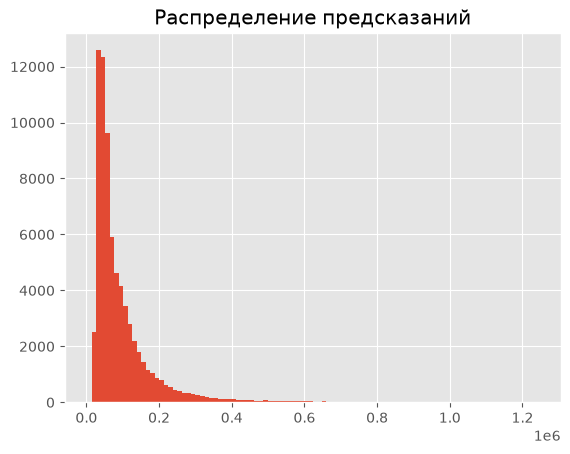

In [ ]:
submission['predict'].hist(bins = 100)
plt.title('Распределение предсказаний')
plt.show()